In [1]:
# ============================================================
# CELL 0: CÀI THƯ VIỆN & IMPORT
# ============================================================
!pip -q install datasets wordcloud textstat gensim nltk umap-learn matplotlib-venn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 37.8 MB/s eta 0:00:00


In [2]:
import os, re, json, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import textstat
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import scipy.stats as stats
from datasets import load_dataset, get_dataset_config_names

In [3]:
warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

True

In [4]:
SEED = 42

# ── Thư mục lưu ảnh ─────────────────────────────────────────
EDA_DIR = Path('/kaggle/working/eda_outputs')
EDA_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    """Lưu figure và in đường dẫn."""
    path = EDA_DIR / name
    plt.savefig(path, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  ✅ Saved → {path}")
    plt.close('all')

STOP_EN = set(stopwords.words('english')) | STOPWORDS | {
    'the','a','an','is','are','was','were','it','its','this','that',
    'these','those','have','has','had','do','does','did','will','would',
    'can','could','may','might','shall','should','must','need','used',
    'also','like','just','even','much','many','most','more','some',
    'than','too','very','well','really','because','since','however',
    'therefore','thus','hence','which','who','what','how','when','where',
    'if','then','but','and','or','not','so','as','at','by','for',
    'in','of','on','to','with','from','about','into','through',
}

PATHS = {
    "scientbank" : "nkazi/SciEntsBank",
    "mohler"     : "nkazi/MohlerASAG",
    "openstax"   : "/kaggle/input/datasets/nguynnghabi/unified-dataset/data_scraping.jsonl",
    "llm"        : "/kaggle/input/datasets/nguynnghabi/unified-dataset/data_generate.jsonl",
}

print("✅ Setup hoàn tất. Thư mục EDA:", EDA_DIR)

✅ Setup hoàn tất. Thư mục EDA: /kaggle/working/eda_outputs


In [5]:
# ============================================================
# CELL 1: LOAD 4 DATASETS
# ============================================================

# ── 1. SciEntsBank ───────────────────────────────────────────
scib_ds   = load_dataset(PATHS["scientbank"])
scib_list = []
for split_name, ds in scib_ds.items():
    tmp = ds.to_pandas().copy()
    tmp['split'] = split_name
    scib_list.append(tmp)
scib_raw = pd.concat(scib_list, ignore_index=True)
scib_raw = scib_raw.rename(columns={
    'id': 'sample_id', 'label': 'label_raw',
    'referenceanswer': 'reference_answer',
    'studentanswer': 'student_answer',
})
scib_raw['source'] = 'SciEntsBank'

# ── 2. Mohler ASAG ───────────────────────────────────────────
mohler_configs = get_dataset_config_names(PATHS["mohler"])
print("Mohler configs:", mohler_configs)

mohler_frames = []
for cfg in mohler_configs:
    ds = load_dataset(PATHS["mohler"], name=cfg)
    for sp, d in ds.items():
        tmp = d.to_pandas().copy()
        tmp['split'] = sp
        tmp['config'] = cfg
        mohler_frames.append(tmp)
mohler_raw = pd.concat(mohler_frames, ignore_index=True)
# Chuẩn hóa tên cột cho mohler (dataset dùng snake_case với underscore)
mohler_raw = mohler_raw.rename(columns={
    'instructor_answer': 'reference_answer',   # instructor_answer → reference_answer
    'score_grader_1': 'score_grader1',          # chuẩn hóa tên grader cols
    'score_grader_2': 'score_grader2',
    # student_answer, score_avg đã đúng sẵn
})
mohler_raw['source'] = 'Mohler'

# ── 3. OpenStax (scraping) ───────────────────────────────────
openstax_raw = pd.read_json(PATHS["openstax"], lines=True)
openstax_raw.columns = [c.strip().lower().replace(' ','_') for c in openstax_raw.columns]
openstax_raw['source'] = 'OpenStax'

# ── 4. LLM Generated ────────────────────────────────────────
llm_raw = pd.read_json(PATHS["llm"], lines=True)
llm_raw.columns = [c.strip().lower().replace(' ','_') for c in llm_raw.columns]
llm_raw['source'] = 'LLM_Generated'

print(f"\n📊 Shape:")
print(f"  SciEntsBank : {scib_raw.shape}")
print(f"  Mohler      : {mohler_raw.shape}")
print(f"  OpenStax    : {openstax_raw.shape}")
print(f"  LLM         : {llm_raw.shape}")

README.md: 0.00B [00:00, ?B/s]

data/train-00001.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

data/test-ua-00001.parquet:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

data/test-uq-00001.parquet:   0%|          | 0.00/35.7k [00:00<?, ?B/s]

data/test-ud-00001.parquet:   0%|          | 0.00/177k [00:00<?, ?B/s]

...

Generating open_ended split:   0%|          | 0/2273 [00:00<?, ? examples/s]

Generating close_ended split:   0%|          | 0/169 [00:00<?, ? examples/s]

data/annotations-00001.parquet:   0%|          | 0.00/15.0k [00:00<?, ?B/s]

Generating annotations split:   0%|          | 0/32 [00:00<?, ? examples/s]


📊 Shape:
  SciEntsBank : (10804, 7)
  Mohler      : (7358, 11)
  OpenStax    : (129, 38)
  LLM         : (10000, 38)


# SciEntsBank

📘 SciEntsBank — Thống kê cơ bản
Tổng mẫu       : 10,804
Số câu hỏi duy nhất : 195
Splits         : {'train': 4969, 'test_ud': 4562, 'test_uq': 733, 'test_ua': 540}

Missing values:
question            0
reference_answer    0
student_answer      0
label_3way          0
dtype: int64


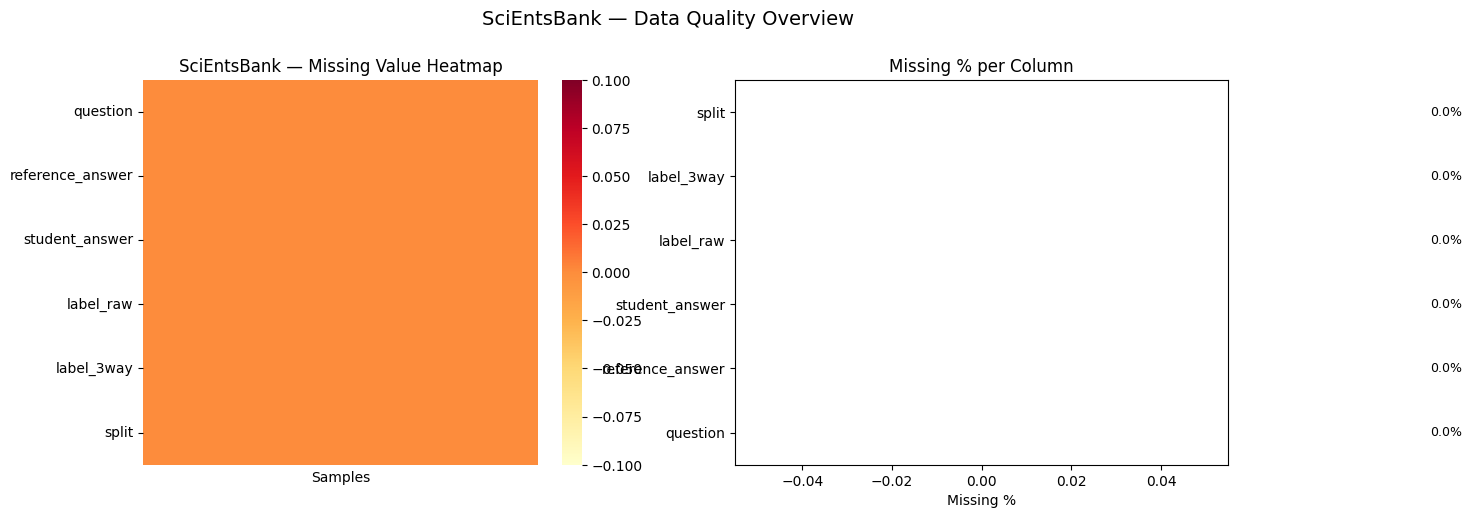

  ✅ Saved → /kaggle/working/eda_outputs/scib_01_missing_values.png


In [6]:
# ============================================================
# CELL 2: [SciEntsBank] THỐNG KÊ CƠ BẢN + MISSING VALUES
# ============================================================
df = scib_raw.copy()

# ── Mapping nhãn ─────────────────────────────────────────────
label_map = {
    0: 'correct', 1: 'partially_correct', 2: 'partially_correct',
    3: 'incorrect', 4: 'incorrect',
}
if df['label_raw'].dtype in [int, float, 'int64', 'float64']:
    df['label_3way'] = df['label_raw'].map(label_map).fillna('unknown')
else:
    df['label_3way'] = df['label_raw'].astype(str).str.lower().str.strip()

# ── Basic stats ───────────────────────────────────────────────
print("=" * 60)
print("📘 SciEntsBank — Thống kê cơ bản")
print("=" * 60)
print(f"Tổng mẫu       : {len(df):,}")
print(f"Số câu hỏi duy nhất : {df['question'].nunique():,}")
print(f"Splits         : {df['split'].value_counts().to_dict()}")
print(f"\nMissing values:")
print(df[['question','reference_answer','student_answer','label_3way']].isnull().sum())

# ── Heatmap missing ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cols_check = ['question','reference_answer','student_answer','label_raw','label_3way','split']
miss = df[cols_check].isnull()
sns.heatmap(miss.T, cbar=True, cmap='YlOrRd', ax=axes[0],
            yticklabels=cols_check, xticklabels=False)
axes[0].set_title('SciEntsBank — Missing Value Heatmap')
axes[0].set_xlabel('Samples')

pct = (miss.sum() / len(df) * 100).sort_values()
pct.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Missing % per Column')
axes[1].set_xlabel('Missing %')
for i, v in enumerate(pct):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('SciEntsBank — Data Quality Overview', fontsize=14, y=1.02)
savefig('scib_01_missing_values.png')
plt.show()

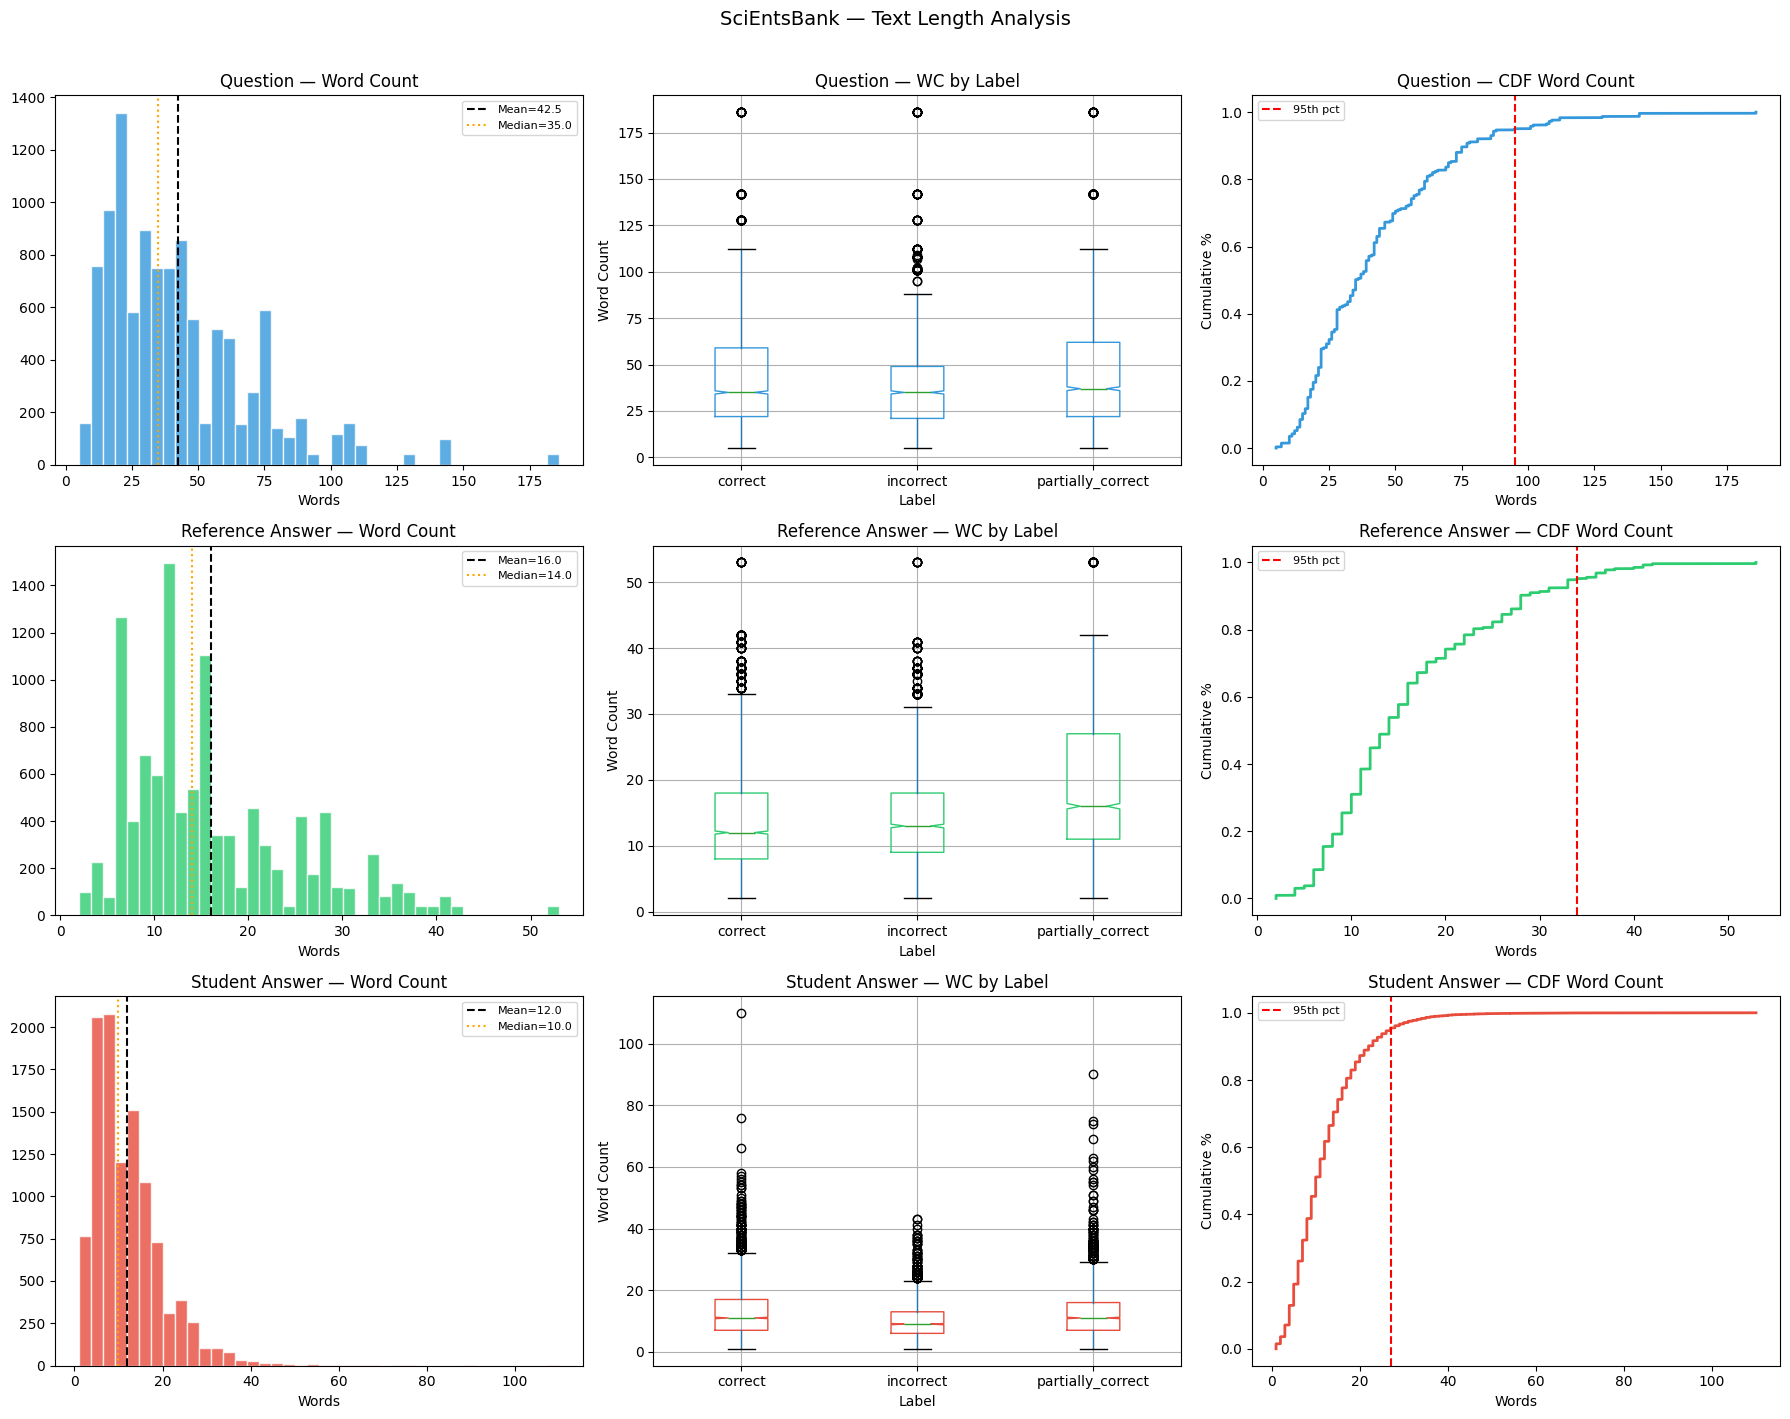

  ✅ Saved → /kaggle/working/eda_outputs/scib_03_text_length.png

📏 question word count:
count    10804.00
mean        42.45
std         27.59
min          5.00
25%         22.00
50%         35.00
75%         57.00
max        186.00

📏 reference_answer word count:
count    10804.00
mean        16.05
std          8.99
min          2.00
25%          9.00
50%         14.00
75%         21.00
max         53.00

📏 student_answer word count:
count    10804.00
mean        12.03
std          7.95
min          1.00
25%          6.00
50%         10.00
75%         16.00
max        110.00


In [7]:
# ============================================================
# CELL 4: [SciEntsBank] PHÂN BỐ ĐỘ DÀI VĂN BẢN
# ============================================================
df = scib_raw.copy()
df['label_3way'] = df['label_raw'].map({0:'correct',1:'partially_correct',
                                         2:'partially_correct',3:'incorrect',4:'incorrect'})

for col in ['question','reference_answer','student_answer']:
    df[f'{col}_wc'] = df[col].fillna('').apply(lambda x: len(str(x).split()))
    df[f'{col}_cc'] = df[col].fillna('').apply(len)
    df[f'{col}_sc'] = df[col].fillna('').apply(
        lambda x: len(re.findall(r'[.!?]+', str(x))) + 1)

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
text_cols = ['question','reference_answer','student_answer']
titles = ['Question','Reference Answer','Student Answer']
colors = ['#3498db','#2ecc71','#e74c3c']

for row, (col, title, color) in enumerate(zip(text_cols, titles, colors)):
    # Word count histogram
    axes[row][0].hist(df[f'{col}_wc'], bins=40, color=color, alpha=0.8, edgecolor='white')
    axes[row][0].axvline(df[f'{col}_wc'].mean(), color='black', linestyle='--',
                          label=f'Mean={df[f"{col}_wc"].mean():.1f}')
    axes[row][0].axvline(df[f'{col}_wc'].median(), color='orange', linestyle=':',
                          label=f'Median={df[f"{col}_wc"].median():.1f}')
    axes[row][0].set_title(f'{title} — Word Count')
    axes[row][0].set_xlabel('Words')
    axes[row][0].legend(fontsize=8)

    # Word count boxplot by label
    df.boxplot(column=f'{col}_wc', by='label_3way', ax=axes[row][1],
               boxprops=dict(color=color), notch=True)
    axes[row][1].set_title(f'{title} — WC by Label')
    axes[row][1].set_xlabel('Label')
    axes[row][1].set_ylabel('Word Count')

    # CDF
    sorted_wc = np.sort(df[f'{col}_wc'])
    cdf = np.arange(1, len(sorted_wc)+1) / len(sorted_wc)
    axes[row][2].plot(sorted_wc, cdf, color=color, linewidth=2)
    axes[row][2].axvline(np.percentile(df[f'{col}_wc'], 95), color='red',
                          linestyle='--', label='95th pct')
    axes[row][2].set_title(f'{title} — CDF Word Count')
    axes[row][2].set_xlabel('Words')
    axes[row][2].set_ylabel('Cumulative %')
    axes[row][2].legend(fontsize=8)

plt.suptitle('SciEntsBank — Text Length Analysis', fontsize=14, y=1.01)
plt.tight_layout()

savefig('scib_03_text_length.png')
plt.show()

# Tóm tắt thống kê
for col in text_cols:
    print(f"\n📏 {col} word count:")
    print(df[f'{col}_wc'].describe().round(2).to_string())

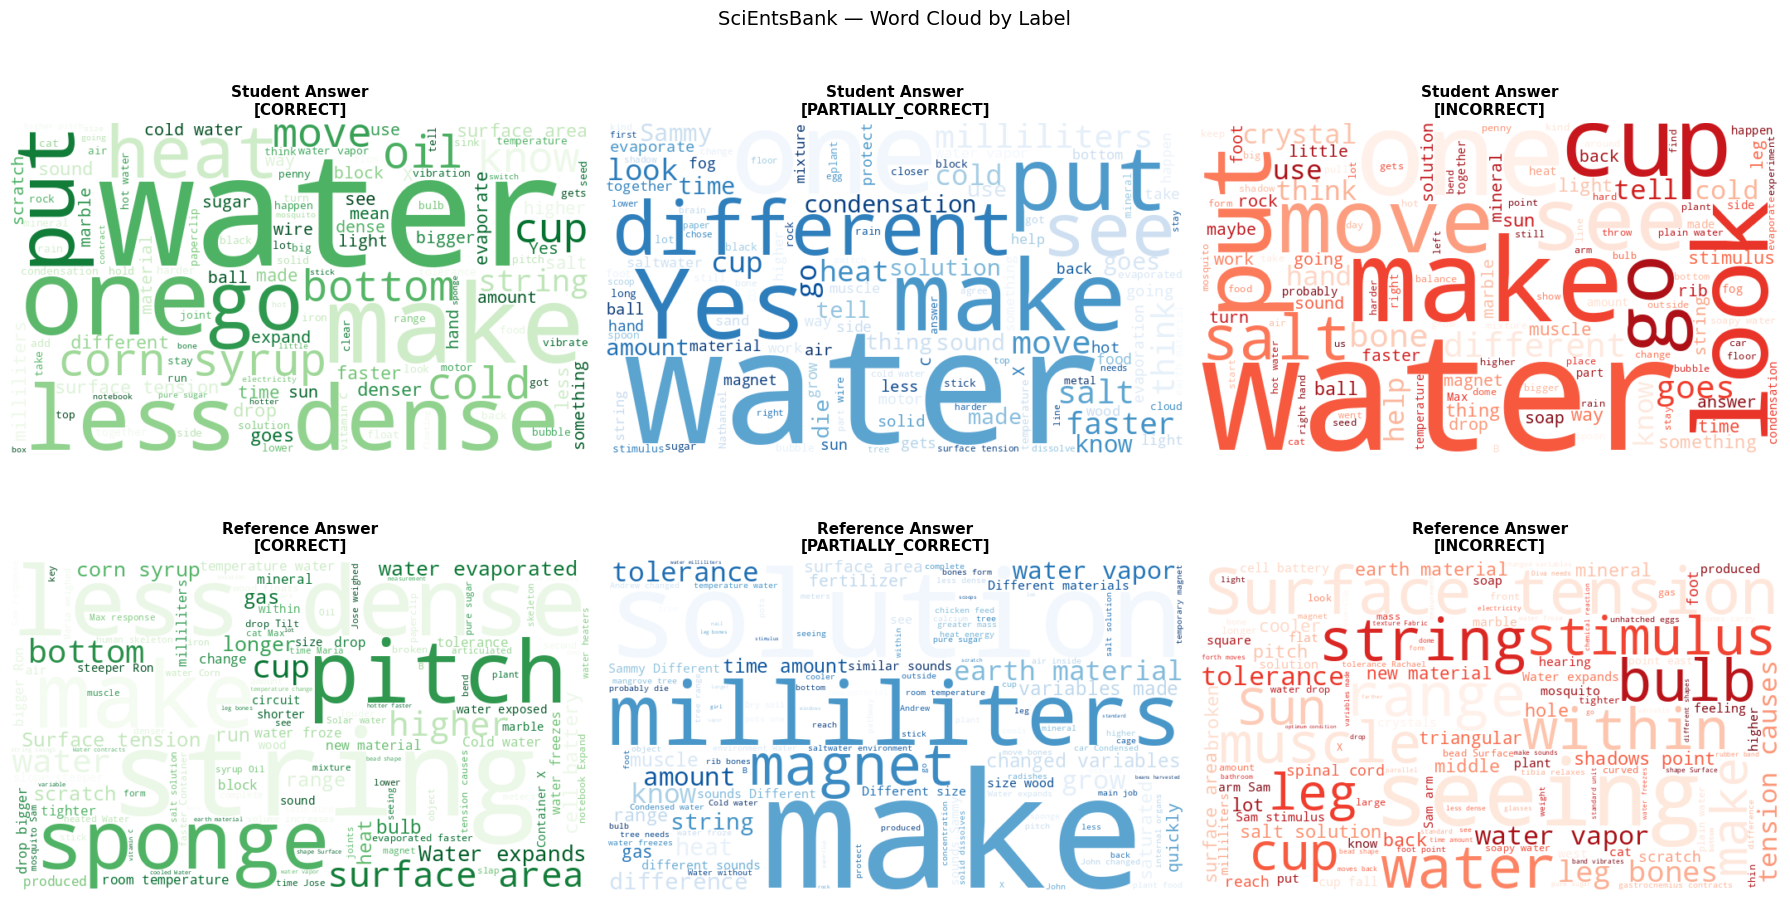

<Figure size 640x480 with 0 Axes>

  ✅ Saved → /kaggle/working/eda_outputs/scib_04_wordcloud_by_label.png


In [8]:
# ============================================================
# CELL 5: [SciEntsBank] WORD CLOUD THEO NHÃN
# ============================================================
df = scib_raw.copy()
df['label_3way'] = df['label_raw'].map({0:'correct',1:'partially_correct',
                                         2:'partially_correct',3:'incorrect',4:'incorrect'})

label_colors = {'correct':'Greens','partially_correct':'Blues','incorrect':'Reds'}
labels_to_plot = ['correct','partially_correct','incorrect']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, text_field in enumerate(['student_answer','reference_answer']):
    for col_i, label in enumerate(labels_to_plot):
        mask = df['label_3way'] == label
        texts = ' '.join(df.loc[mask, text_field].fillna('').astype(str).tolist())
        wc = WordCloud(
            width=700, height=400,
            background_color='white',
            stopwords=STOP_EN,
            colormap=label_colors.get(label,'viridis'),
            max_words=120,
            collocations=True,
            random_state=SEED,
        ).generate(texts)
        axes[row][col_i].imshow(wc, interpolation='bilinear')
        axes[row][col_i].axis('off')
        field_label = 'Student Answer' if text_field == 'student_answer' else 'Reference Answer'
        axes[row][col_i].set_title(f'{field_label}\n[{label.upper()}]',
                                    fontsize=11, fontweight='bold')

plt.suptitle('SciEntsBank — Word Cloud by Label', fontsize=14)
plt.tight_layout()
plt.show()
savefig('scib_04_wordcloud_by_label.png')

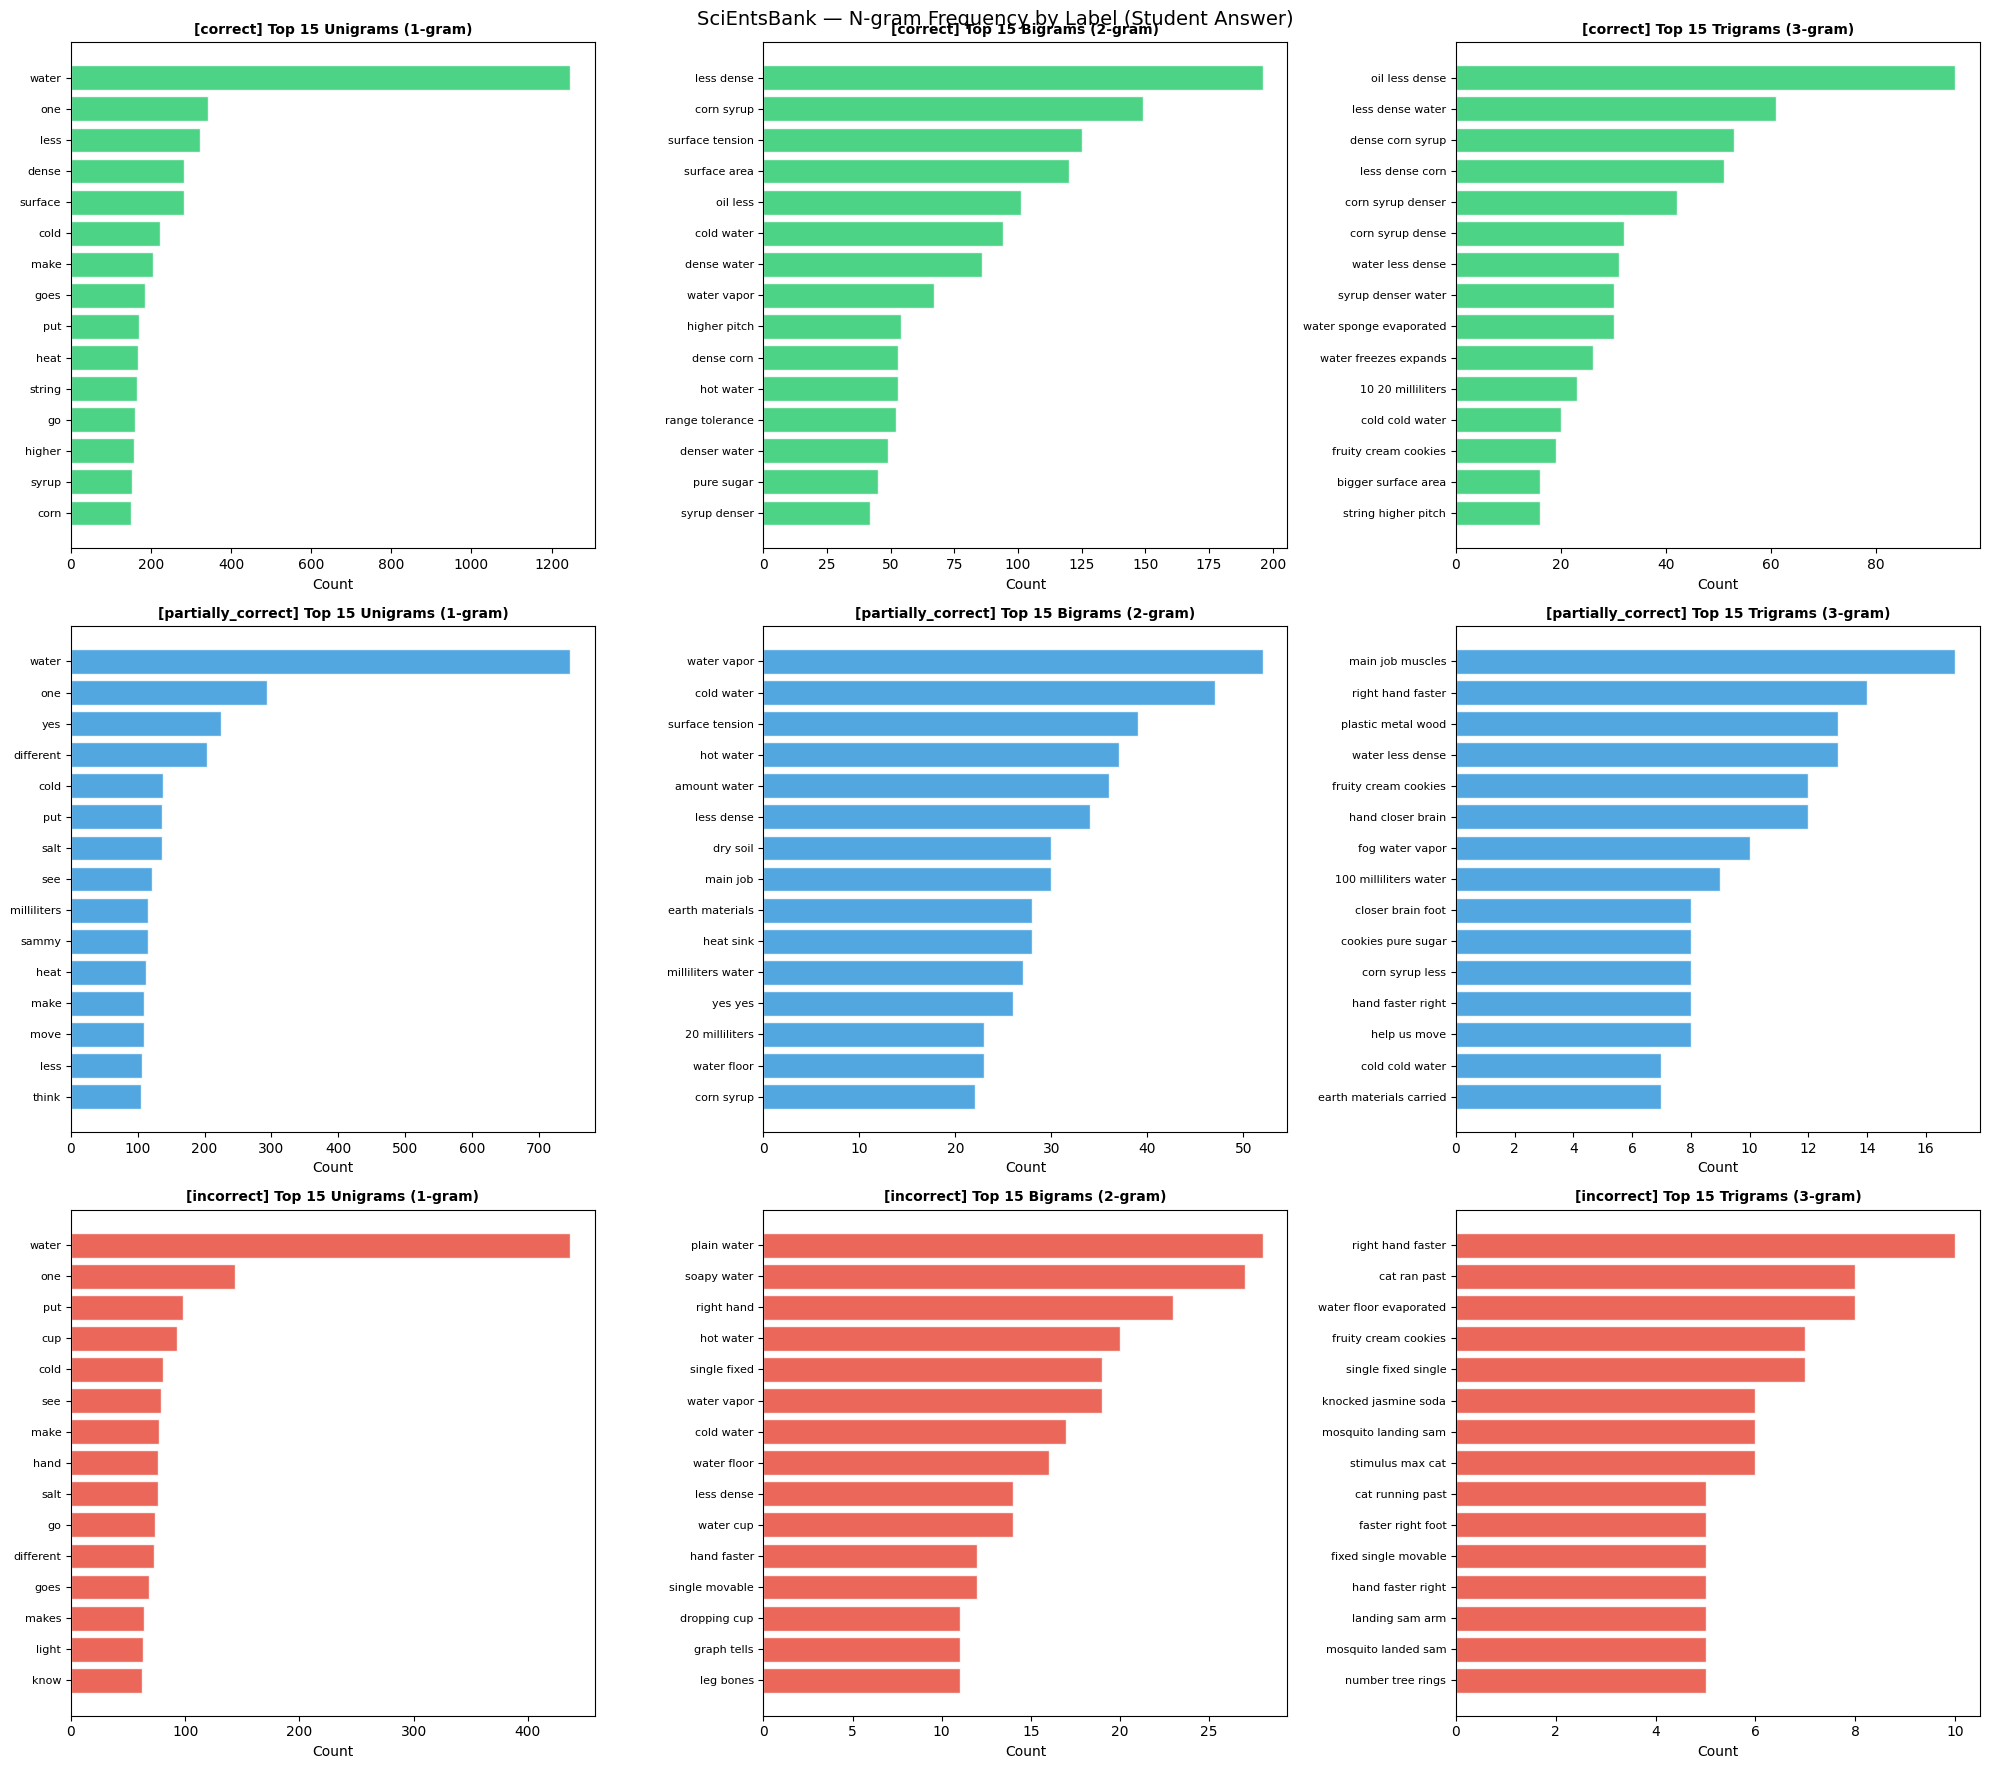

<Figure size 640x480 with 0 Axes>

  ✅ Saved → /kaggle/working/eda_outputs/scib_05_ngrams_by_label.png


In [9]:
# ============================================================
# CELL 6: [SciEntsBank] TOP UNIGRAMS / BIGRAMS / TRIGRAMS
# ============================================================
df = scib_raw.copy()
df['label_3way'] = df['label_raw'].map({0:'correct',1:'partially_correct',
                                         2:'partially_correct',3:'incorrect',4:'incorrect'})

def get_top_ngrams(corpus, n=1, top_k=20, stop=STOP_EN):
    vec = CountVectorizer(ngram_range=(n,n), stop_words=list(stop),
                          max_features=5000, min_df=2)
    try:
        X = vec.fit_transform(corpus.fillna('').astype(str))
        counts = X.sum(axis=0).A1
        vocab  = vec.get_feature_names_out()
        freq   = sorted(zip(vocab, counts), key=lambda x: -x[1])
        return freq[:top_k]
    except:
        return []

fig, axes = plt.subplots(3, 3, figsize=(20, 18))
labels = ['correct','partially_correct','incorrect']
label_colors_bar = {'correct':'#2ecc71','partially_correct':'#3498db','incorrect':'#e74c3c'}
ng_titles = ['Unigrams (1-gram)','Bigrams (2-gram)','Trigrams (3-gram)']

for row, label in enumerate(labels):
    mask = df['label_3way'] == label
    corpus = df.loc[mask, 'student_answer']
    for col_i, n in enumerate([1, 2, 3]):
        freq = get_top_ngrams(corpus, n=n, top_k=15)
        if not freq:
            axes[row][col_i].set_visible(False)
            continue
        words, cnts = zip(*freq)
        y_pos = range(len(words))
        axes[row][col_i].barh(list(y_pos), list(cnts),
                               color=label_colors_bar[label], alpha=0.85, edgecolor='white')
        axes[row][col_i].set_yticks(list(y_pos))
        axes[row][col_i].set_yticklabels(list(words), fontsize=8)
        axes[row][col_i].invert_yaxis()
        axes[row][col_i].set_title(f'[{label}] Top 15 {ng_titles[col_i]}',
                                    fontsize=10, fontweight='bold')
        axes[row][col_i].set_xlabel('Count')

plt.suptitle('SciEntsBank — N-gram Frequency by Label (Student Answer)', fontsize=14)
plt.tight_layout()
plt.show()
savefig('scib_05_ngrams_by_label.png')

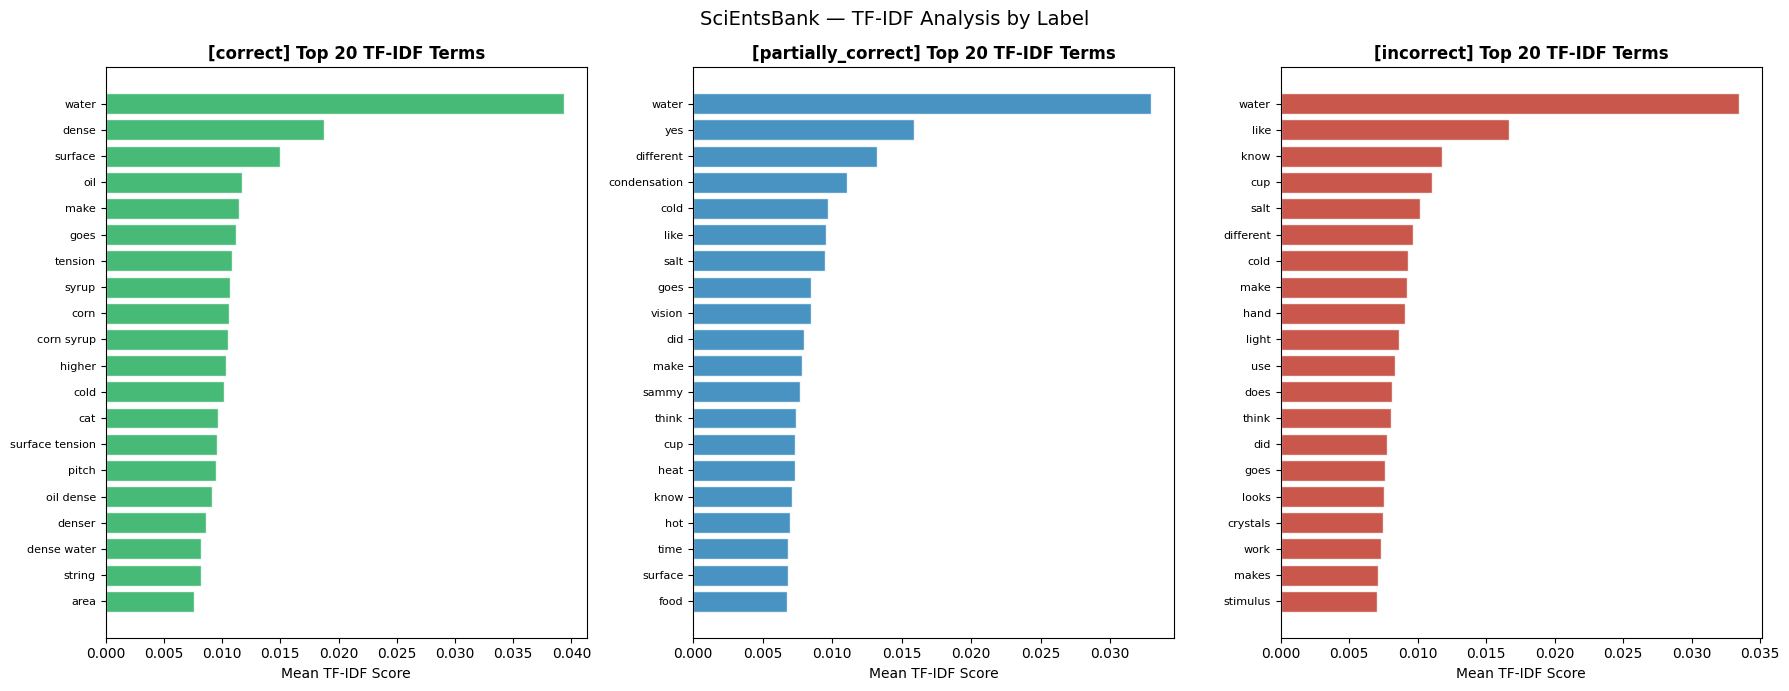

<Figure size 640x480 with 0 Axes>

  ✅ Saved → /kaggle/working/eda_outputs/scib_06_tfidf_by_label.png


In [10]:
# ============================================================
# CELL 7: [SciEntsBank] TF-IDF TOP TERMS PER LABEL
# ============================================================
df = scib_raw.copy()
df['label_3way'] = df['label_raw'].map({0:'correct',1:'partially_correct',
                                         2:'partially_correct',3:'incorrect',4:'incorrect'})

labels = ['correct','partially_correct','incorrect']
colors = ['#27ae60','#2980b9','#c0392b']
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, label, color in zip(axes, labels, colors):
    mask = df['label_3way'] == label
    corpus = df.loc[mask, 'student_answer'].fillna('').astype(str).tolist()
    tfidf = TfidfVectorizer(stop_words='english', max_features=5000,
                            ngram_range=(1,2), min_df=2)
    X = tfidf.fit_transform(corpus)
    scores = X.mean(axis=0).A1
    vocab  = tfidf.get_feature_names_out()
    top20  = sorted(zip(vocab, scores), key=lambda x: -x[1])[:20]
    words, vals = zip(*top20)
    y_pos = range(len(words))
    ax.barh(list(y_pos), list(vals), color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(list(words), fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'[{label}] Top 20 TF-IDF Terms', fontweight='bold')
    ax.set_xlabel('Mean TF-IDF Score')

plt.suptitle('SciEntsBank — TF-IDF Analysis by Label', fontsize=14)
plt.tight_layout()
plt.show()
savefig('scib_06_tfidf_by_label.png')

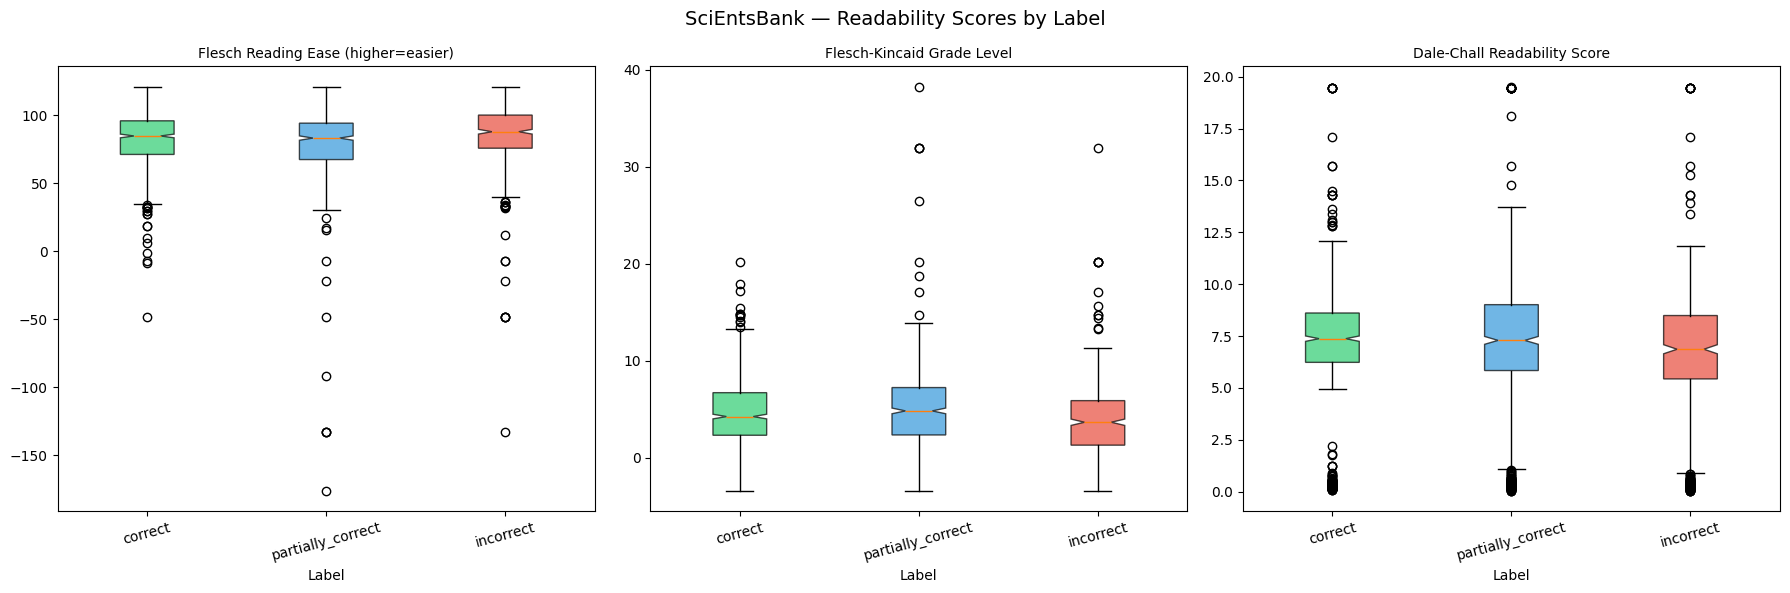

  ✅ Saved → /kaggle/working/eda_outputs/scib_07_readability.png


In [11]:
# ============================================================
# CELL 8: [SciEntsBank] READABILITY SCORES
# ============================================================
df = scib_raw.copy()
df['label_3way'] = df['label_raw'].map({0:'correct',1:'partially_correct',
                                         2:'partially_correct',3:'incorrect',4:'incorrect'})

sample = df.sample(min(2000, len(df)), random_state=SEED)

def safe_flesch(text):
    try:
        return textstat.flesch_reading_ease(str(text))
    except:
        return np.nan

def safe_fk(text):
    try:
        return textstat.flesch_kincaid_grade(str(text))
    except:
        return np.nan

def safe_dcrs(text):
    try:
        return textstat.dale_chall_readability_score(str(text))
    except:
        return np.nan

sample['flesch']   = sample['student_answer'].map(safe_flesch)
sample['fk_grade'] = sample['student_answer'].map(safe_fk)
sample['dale_chall']= sample['student_answer'].map(safe_dcrs)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
readability_metrics = [
    ('flesch',   'Flesch Reading Ease (higher=easier)'),
    ('fk_grade', 'Flesch-Kincaid Grade Level'),
    ('dale_chall','Dale-Chall Readability Score'),
]
colors = ['#3498db','#e74c3c','#2ecc71']

for ax, (metric, title), color in zip(axes, readability_metrics, colors):
    label_order = ['correct','partially_correct','incorrect']
    data_by_label = [sample[sample['label_3way']==l][metric].dropna().values
                     for l in label_order]
    bp = ax.boxplot(data_by_label, labels=label_order, patch_artist=True, notch=True)
    for patch, c in zip(bp['boxes'], ['#2ecc71','#3498db','#e74c3c']):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Label')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('SciEntsBank — Readability Scores by Label', fontsize=14)
plt.tight_layout()
savefig('scib_07_readability.png')

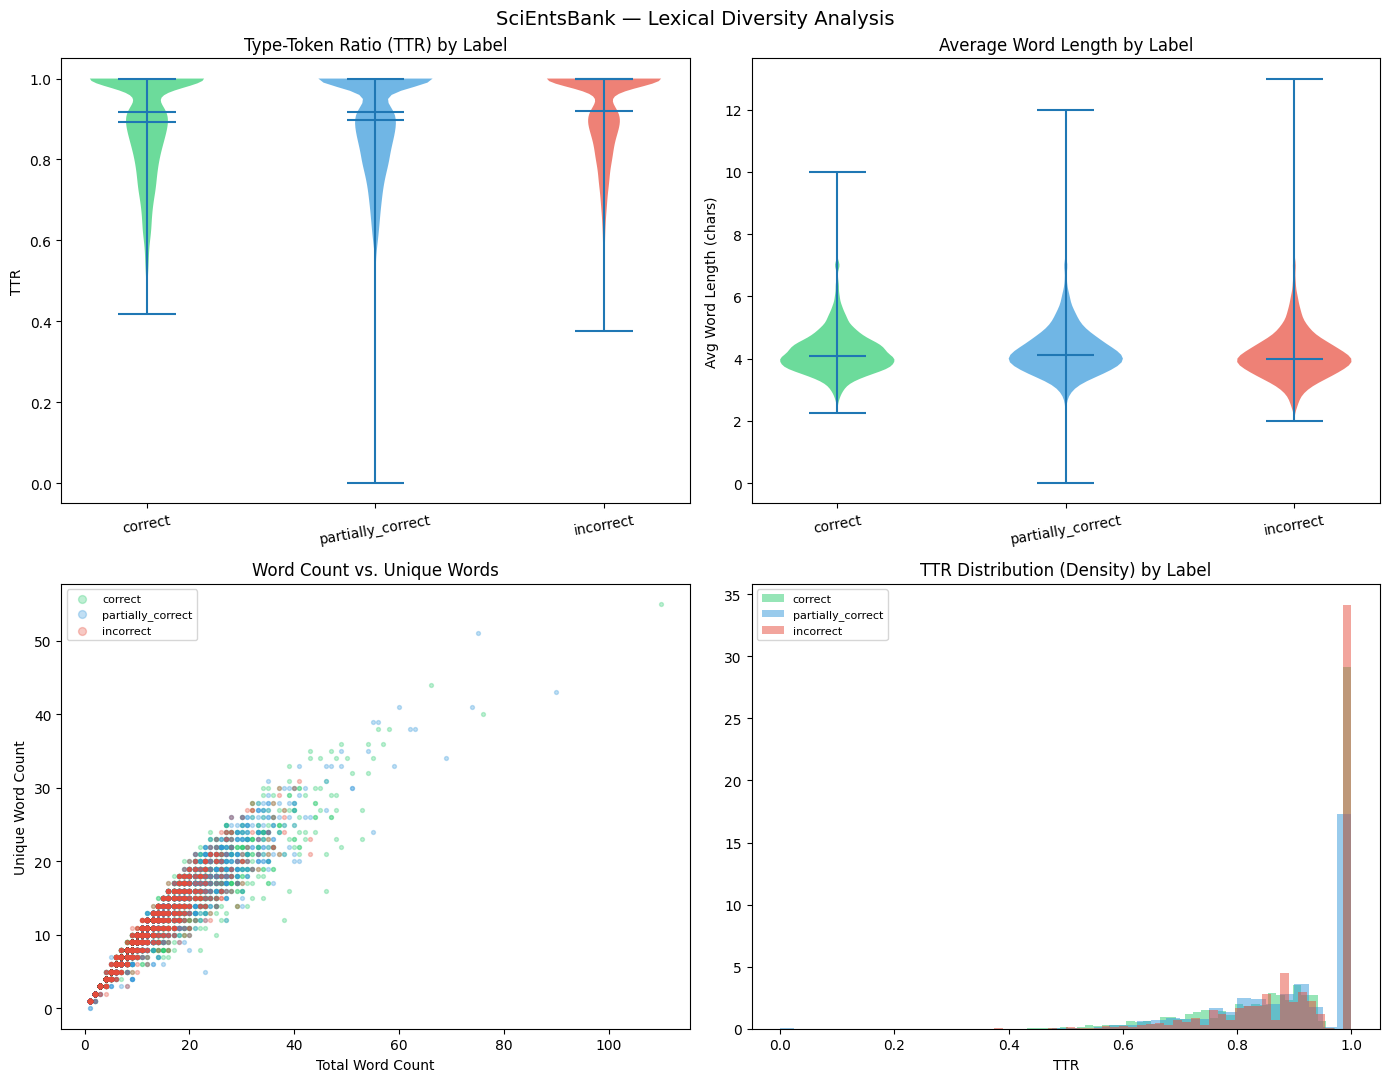

  ✅ Saved → /kaggle/working/eda_outputs/scib_08_lexical_diversity.png


In [12]:
# ============================================================
# CELL 9: [SciEntsBank] VOCABULARY RICHNESS & LEXICAL DIVERSITY
# ============================================================
df = scib_raw.copy()
df['label_3way'] = df['label_raw'].map({0:'correct',1:'partially_correct',
                                         2:'partially_correct',3:'incorrect',4:'incorrect'})

def ttr(text):
    """Type-Token Ratio = unique_words / total_words"""
    words = re.findall(r'\b[a-z]+\b', str(text).lower())
    if not words: return 0
    return len(set(words)) / len(words)

def avg_word_len(text):
    words = re.findall(r'\b[a-z]+\b', str(text).lower())
    if not words: return 0
    return np.mean([len(w) for w in words])

df['ttr']          = df['student_answer'].fillna('').map(ttr)
df['avg_word_len'] = df['student_answer'].fillna('').map(avg_word_len)
df['unique_words'] = df['student_answer'].fillna('').apply(
    lambda x: len(set(re.findall(r'\b[a-z]+\b', str(x).lower()))))
df['word_count']   = df['student_answer'].fillna('').apply(
    lambda x: len(str(x).split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# TTR violin
parts = axes[0][0].violinplot(
    [df[df['label_3way']==l]['ttr'].dropna().values for l in ['correct','partially_correct','incorrect']],
    positions=[1,2,3], showmedians=True, showmeans=True)
for pc, color in zip(parts['bodies'], ['#2ecc71','#3498db','#e74c3c']):
    pc.set_facecolor(color); pc.set_alpha(0.7)
axes[0][0].set_xticks([1,2,3])
axes[0][0].set_xticklabels(['correct','partially_correct','incorrect'], rotation=10)
axes[0][0].set_title('Type-Token Ratio (TTR) by Label')
axes[0][0].set_ylabel('TTR')

# Avg word length
parts2 = axes[0][1].violinplot(
    [df[df['label_3way']==l]['avg_word_len'].dropna().values for l in ['correct','partially_correct','incorrect']],
    positions=[1,2,3], showmedians=True)
for pc, color in zip(parts2['bodies'], ['#2ecc71','#3498db','#e74c3c']):
    pc.set_facecolor(color); pc.set_alpha(0.7)
axes[0][1].set_xticks([1,2,3])
axes[0][1].set_xticklabels(['correct','partially_correct','incorrect'], rotation=10)
axes[0][1].set_title('Average Word Length by Label')
axes[0][1].set_ylabel('Avg Word Length (chars)')

# Scatter word count vs unique words
for label, color in [('correct','#2ecc71'),('partially_correct','#3498db'),('incorrect','#e74c3c')]:
    mask = df['label_3way'] == label
    axes[1][0].scatter(df.loc[mask,'word_count'], df.loc[mask,'unique_words'],
                        alpha=0.3, s=8, color=color, label=label)
axes[1][0].set_xlabel('Total Word Count')
axes[1][0].set_ylabel('Unique Word Count')
axes[1][0].set_title('Word Count vs. Unique Words')
axes[1][0].legend(markerscale=2, fontsize=8)

# TTR distribution histogram overlay
for label, color in [('correct','#2ecc71'),('partially_correct','#3498db'),('incorrect','#e74c3c')]:
    mask = df['label_3way'] == label
    axes[1][1].hist(df.loc[mask,'ttr'], bins=40, alpha=0.5, color=color, label=label, density=True)
axes[1][1].set_title('TTR Distribution (Density) by Label')
axes[1][1].set_xlabel('TTR')
axes[1][1].legend(fontsize=8)

plt.suptitle('SciEntsBank — Lexical Diversity Analysis', fontsize=14)
plt.tight_layout()
savefig('scib_08_lexical_diversity.png')

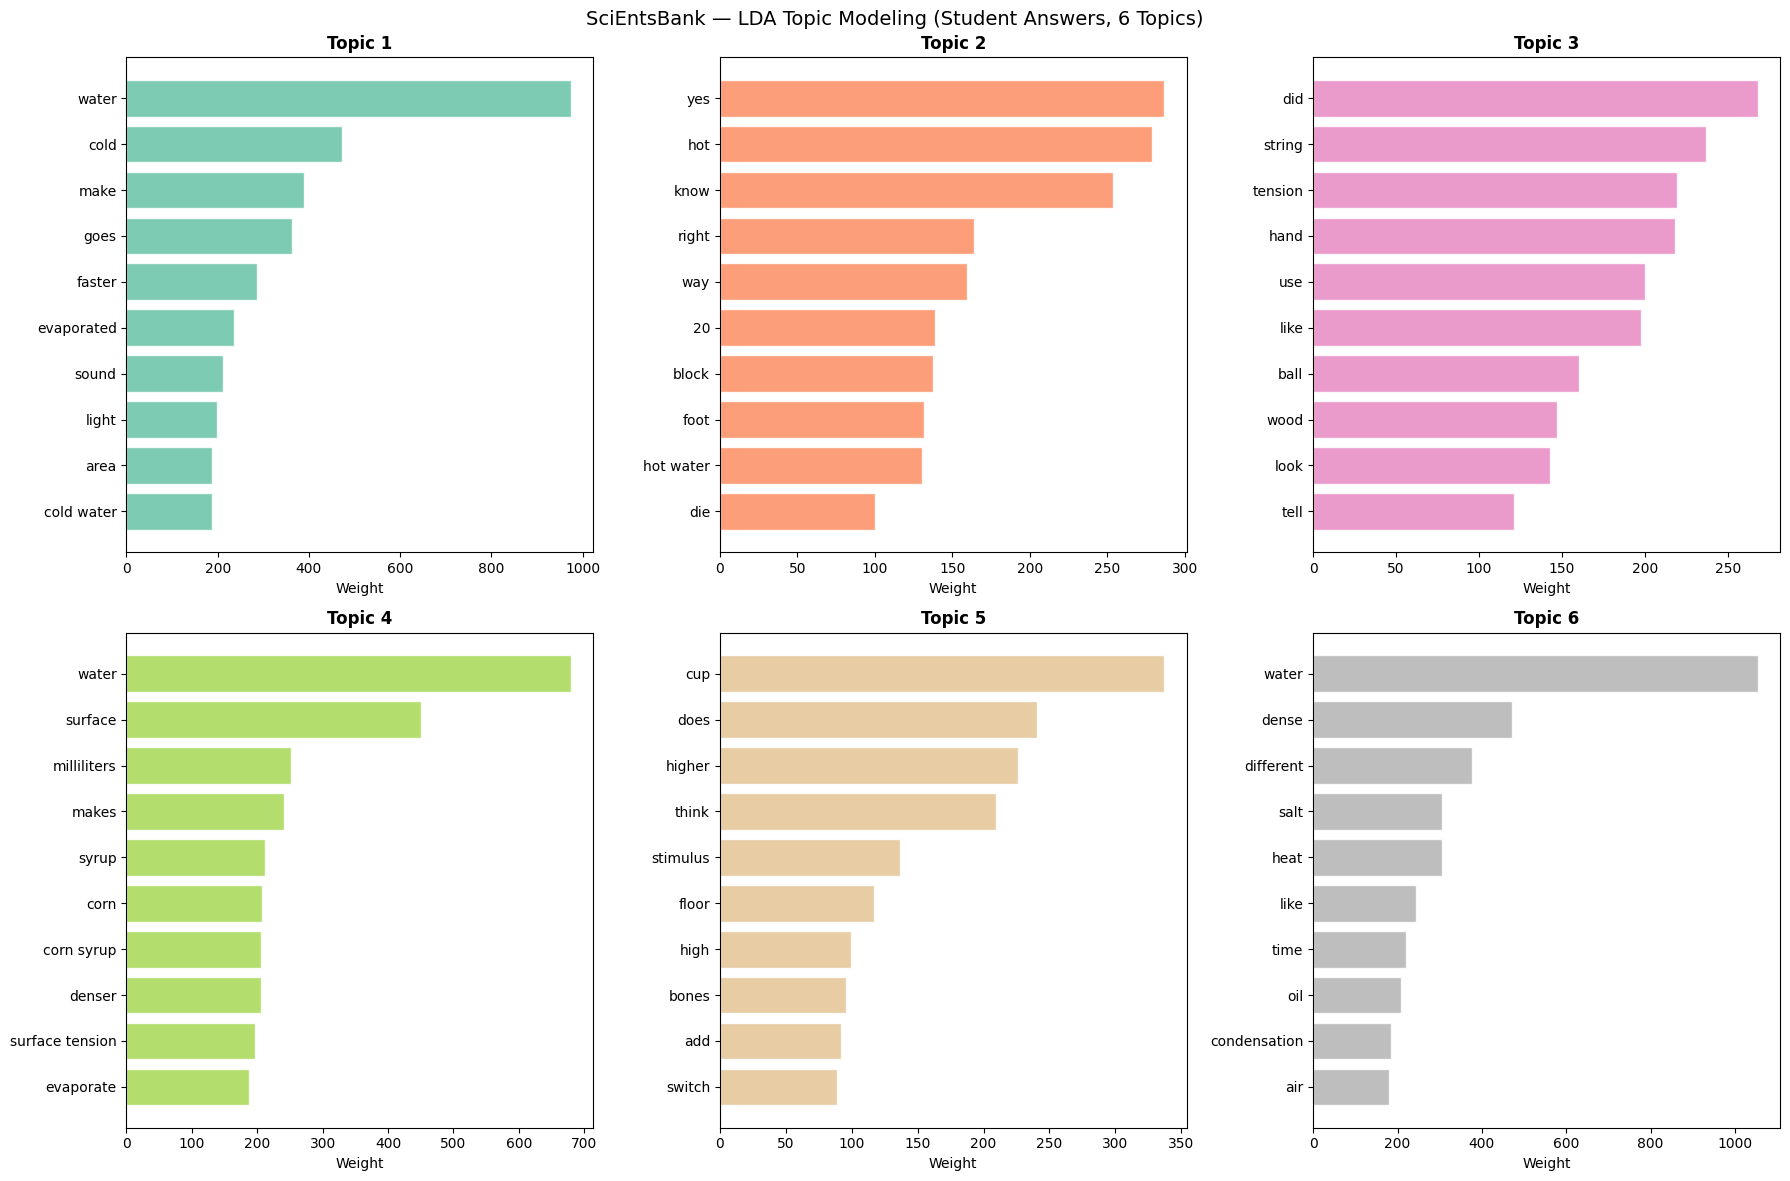

  ✅ Saved → /kaggle/working/eda_outputs/scib_09_lda_topics.png


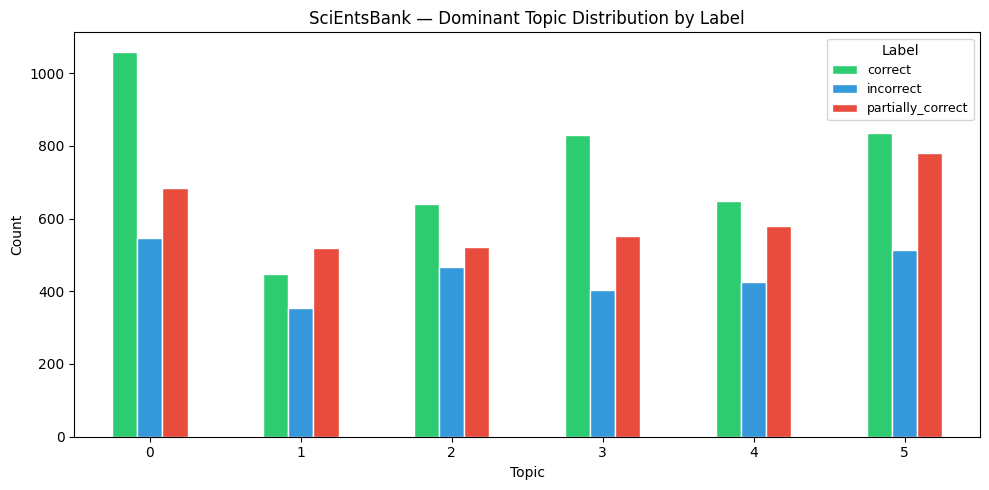

  ✅ Saved → /kaggle/working/eda_outputs/scib_10_lda_topic_by_label.png


In [13]:
# ============================================================
# CELL 10: [SciEntsBank] LDA TOPIC MODELING (student_answer)
# ============================================================
df = scib_raw.copy()
df['label_3way'] = df['label_raw'].map({0:'correct',1:'partially_correct',
                                         2:'partially_correct',3:'incorrect',4:'incorrect'})

N_TOPICS = 6
corpus = df['student_answer'].fillna('').astype(str)

cv = CountVectorizer(stop_words='english', max_features=3000,
                     min_df=3, ngram_range=(1,2))
X  = cv.fit_transform(corpus)

lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=SEED,
                                  learning_method='online', max_iter=20)
lda.fit(X)

vocab = cv.get_feature_names_out()
top_n = 10

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
topic_colors = plt.cm.Set2(np.linspace(0, 1, N_TOPICS))

for i, (ax, color) in enumerate(zip(axes.flatten(), topic_colors)):
    top_idx    = lda.components_[i].argsort()[-top_n:][::-1]
    top_words  = [vocab[j] for j in top_idx]
    top_scores = lda.components_[i][top_idx]
    ax.barh(top_words[::-1], top_scores[::-1], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Topic {i+1}', fontweight='bold')
    ax.set_xlabel('Weight')

plt.suptitle('SciEntsBank — LDA Topic Modeling (Student Answers, 6 Topics)', fontsize=14)
plt.tight_layout()
savefig('scib_09_lda_topics.png')

# Topic distribution by label
topic_probs = lda.transform(X)
df['dominant_topic'] = topic_probs.argmax(axis=1)
topic_label_dist = df.groupby(['dominant_topic','label_3way']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
topic_label_dist.plot(kind='bar', ax=ax, color=['#2ecc71','#3498db','#e74c3c'],
                       edgecolor='white', rot=0)
ax.set_title('SciEntsBank — Dominant Topic Distribution by Label')
ax.set_xlabel('Topic')
ax.set_ylabel('Count')
ax.legend(title='Label', fontsize=9)
plt.tight_layout()
savefig('scib_10_lda_topic_by_label.png')

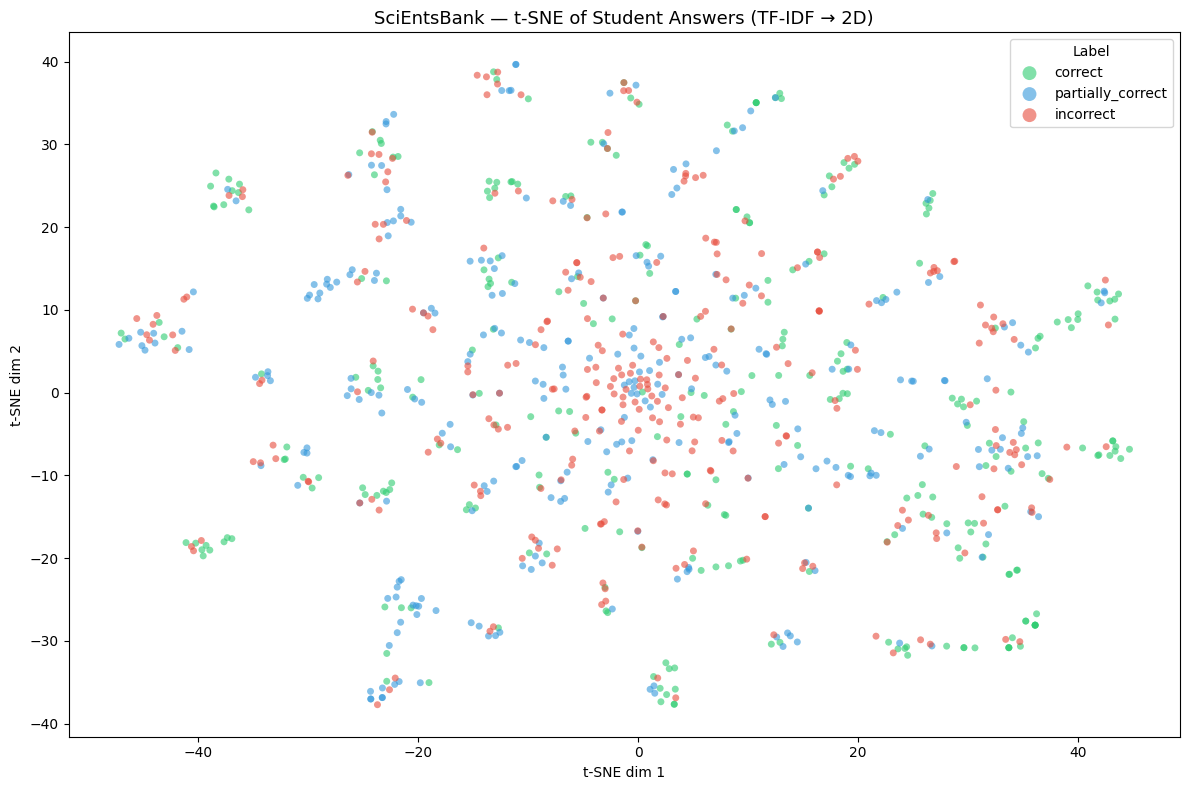

  ✅ Saved → /kaggle/working/eda_outputs/scib_11_tsne_tfidf.png


In [14]:
# ============================================================
# CELL 11: [SciEntsBank] t-SNE EMBEDDING (TF-IDF → 2D)
# ============================================================
df_sample = scib_raw.copy()
df_sample['label_3way'] = df_sample['label_raw'].map(
    {0:'correct',1:'partially_correct',2:'partially_correct',3:'incorrect',4:'incorrect'})

# Subsample vì t-SNE chậm
df_sub = df_sample.groupby('label_3way').apply(
    lambda g: g.sample(min(300, len(g)), random_state=SEED)
).reset_index(drop=True)

tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X_tfidf = tfidf.fit_transform(df_sub['student_answer'].fillna('').astype(str))

# SVD trước khi t-SNE (giảm chiều)
svd = TruncatedSVD(n_components=50, random_state=SEED)
X_svd = svd.fit_transform(X_tfidf)

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
X_2d = tsne.fit_transform(X_svd)

fig, ax = plt.subplots(figsize=(12, 8))
label_color_map = {'correct':'#2ecc71','partially_correct':'#3498db','incorrect':'#e74c3c'}
for label, color in label_color_map.items():
    mask = df_sub['label_3way'] == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=label, alpha=0.6, s=25, edgecolors='none')
ax.set_title('SciEntsBank — t-SNE of Student Answers (TF-IDF → 2D)', fontsize=13)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(title='Label', markerscale=2)
plt.tight_layout()
savefig('scib_11_tsne_tfidf.png')

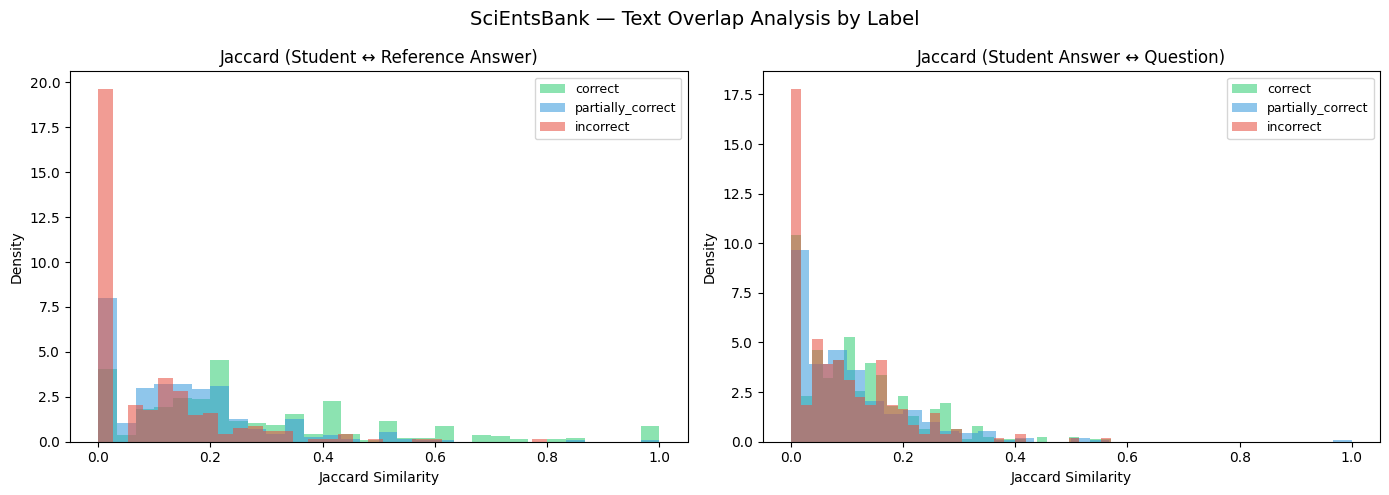

  ✅ Saved → /kaggle/working/eda_outputs/scib_12_jaccard_overlap.png

Mean Jaccard (Student ↔ Reference) by label:
label_3way
correct              0.2650
incorrect            0.0877
partially_correct    0.1443
Name: jac_stu_ref, dtype: float64


In [15]:
# ============================================================
# CELL 12: [SciEntsBank] SEMANTIC SIMILARITY (Q vs Ref vs Student)
# ============================================================
df = scib_raw.copy()
df['label_3way'] = df['label_raw'].map({0:'correct',1:'partially_correct',
                                         2:'partially_correct',3:'incorrect',4:'incorrect'})
df_sample = df.sample(min(1000, len(df)), random_state=SEED)

def jaccard_similarity(a, b):
    a_set = set(re.findall(r'\b[a-z]+\b', str(a).lower())) - STOP_EN
    b_set = set(re.findall(r'\b[a-z]+\b', str(b).lower())) - STOP_EN
    if not a_set or not b_set: return 0.0
    return len(a_set & b_set) / len(a_set | b_set)

df_sample['jac_stu_ref'] = df_sample.apply(
    lambda r: jaccard_similarity(r['student_answer'], r['reference_answer']), axis=1)
df_sample['jac_stu_q']  = df_sample.apply(
    lambda r: jaccard_similarity(r['student_answer'], r['question']), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'jac_stu_ref', 'Jaccard (Student ↔ Reference Answer)'),
    (axes[1], 'jac_stu_q',   'Jaccard (Student Answer ↔ Question)'),
]:
    for label, color in [('correct','#2ecc71'),('partially_correct','#3498db'),('incorrect','#e74c3c')]:
        mask = df_sample['label_3way'] == label
        ax.hist(df_sample.loc[mask, col], bins=30, alpha=0.55, color=color, label=label, density=True)
    ax.set_title(title)
    ax.set_xlabel('Jaccard Similarity')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('SciEntsBank — Text Overlap Analysis by Label', fontsize=14)
plt.tight_layout()
savefig('scib_12_jaccard_overlap.png')
print("\nMean Jaccard (Student ↔ Reference) by label:")
print(df_sample.groupby('label_3way')['jac_stu_ref'].mean().round(4))

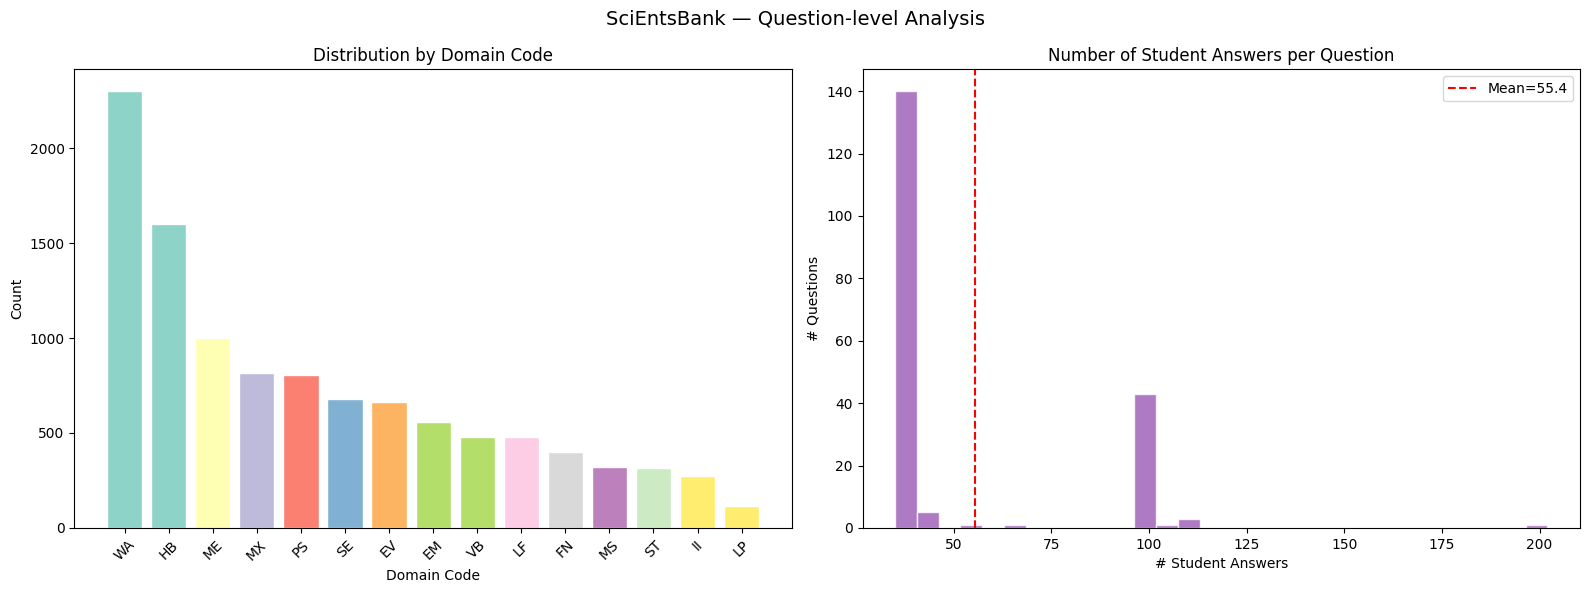

  ✅ Saved → /kaggle/working/eda_outputs/scib_13_domain_question.png


In [16]:
# ============================================================
# CELL 13: [SciEntsBank] PHÂN BỐ CÂU HỎI THEO DOMAIN/QUESTION_ID
# ============================================================
df = scib_raw.copy()
df['label_3way'] = df['label_raw'].map({0:'correct',1:'partially_correct',
                                         2:'partially_correct',3:'incorrect',4:'incorrect'})

# Trích prefix domain từ ID (VD: "EM.45b" → "EM")
df['domain_code'] = df.get('sample_id', df.get('id', pd.Series(['UNK']*len(df)))).fillna('UNK').apply(
    lambda x: str(x).split('.')[0] if '.' in str(x) else str(x)[:2]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

domain_counts = df['domain_code'].value_counts()
axes[0].bar(domain_counts.index, domain_counts.values,
             color=plt.cm.Set3(np.linspace(0, 1, len(domain_counts))),
             edgecolor='white')
axes[0].set_title('Distribution by Domain Code')
axes[0].set_xlabel('Domain Code')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Answers per question distribution
q_counts = df['question'].value_counts()
axes[1].hist(q_counts.values, bins=30, color='#9b59b6', alpha=0.8, edgecolor='white')
axes[1].set_title('Number of Student Answers per Question')
axes[1].set_xlabel('# Student Answers')
axes[1].set_ylabel('# Questions')
axes[1].axvline(q_counts.mean(), color='red', linestyle='--',
                 label=f'Mean={q_counts.mean():.1f}')
axes[1].legend()

plt.suptitle('SciEntsBank — Question-level Analysis', fontsize=14)
plt.tight_layout()
savefig('scib_13_domain_question.png')

# Mohler

📗 Mohler ASAG — Thống kê
Tổng mẫu         : 7,358
Câu hỏi duy nhất : 255

Label 3-way:
label_3way
correct              5313
partially_correct    1722
incorrect             323
Name: count, dtype: int64

Score thống kê:
count    7326.00
mean        4.19
std         1.11
min         0.00
25%         3.50
50%         5.00
75%         5.00
max         5.00
Name: score_avg, dtype: float64


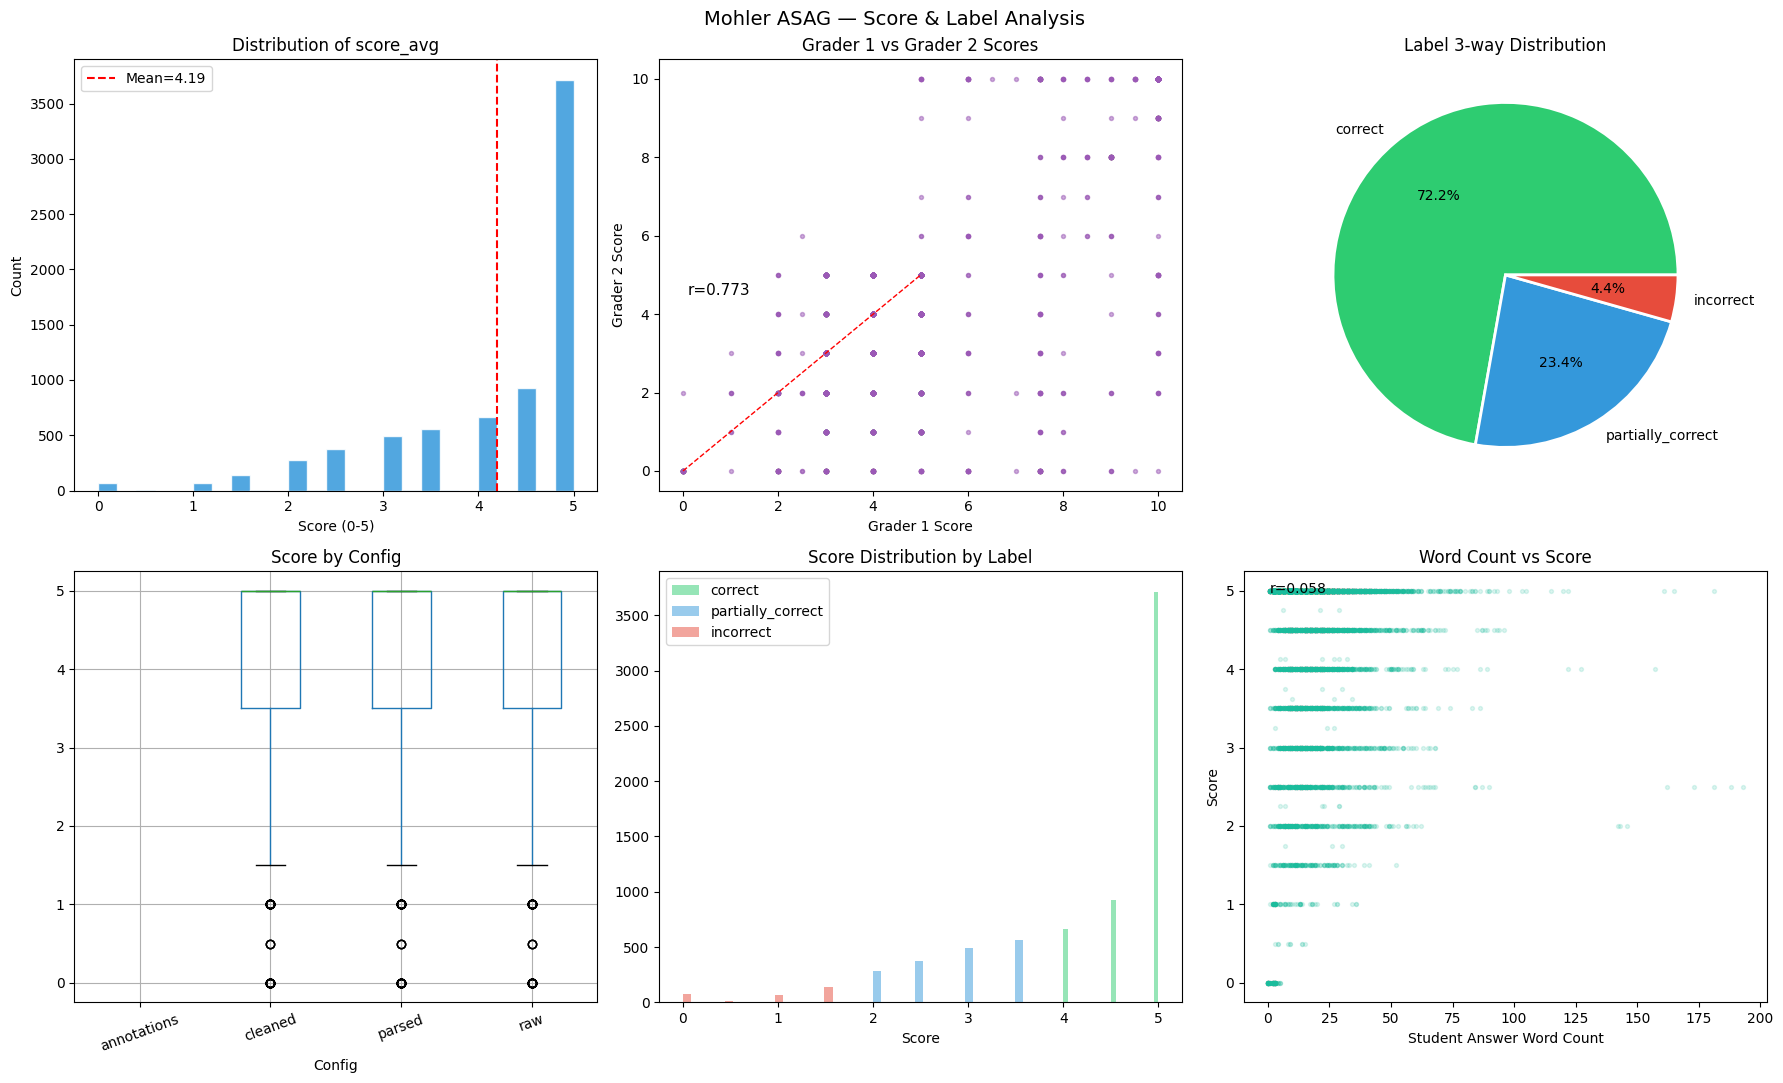

  ✅ Saved → /kaggle/working/eda_outputs/mohler_01_score_label.png


In [17]:
# ============================================================
# CELL 14: [Mohler] THỐNG KÊ + PHÂN BỐ ĐIỂM SỐ
# ============================================================
df = mohler_raw.copy()

# Tạo label 3-way từ score
def score_to_label(score):
    try:
        s = float(score)
        if s >= 4.0: return 'correct'
        if s >= 2.0: return 'partially_correct'
        return 'incorrect'
    except: return 'unknown'

df['label_3way'] = df['score_avg'].map(score_to_label)

print("=" * 60)
print("📗 Mohler ASAG — Thống kê")
print("=" * 60)
print(f"Tổng mẫu         : {len(df):,}")
print(f"Câu hỏi duy nhất : {df['question'].nunique():,}")
print(f"\nLabel 3-way:\n{df['label_3way'].value_counts()}")
print(f"\nScore thống kê:\n{df['score_avg'].dropna().describe().round(2)}")

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Score histogram
axes[0][0].hist(df['score_avg'].dropna(), bins=25, color='#3498db', edgecolor='white', alpha=0.85)
axes[0][0].set_title('Distribution of score_avg')
axes[0][0].set_xlabel('Score (0-5)')
axes[0][0].set_ylabel('Count')
axes[0][0].axvline(df['score_avg'].mean(), color='red', linestyle='--',
                    label=f"Mean={df['score_avg'].mean():.2f}")
axes[0][0].legend()

# Grader 1 vs Grader 2 scatter
if 'score_grader1' in df.columns and 'score_grader2' in df.columns:
    axes[0][1].scatter(df['score_grader1'].dropna(), df['score_grader2'].dropna(),
                        alpha=0.2, s=8, color='#9b59b6')
    axes[0][1].plot([0,5],[0,5], 'r--', linewidth=1)
    axes[0][1].set_title('Grader 1 vs Grader 2 Scores')
    axes[0][1].set_xlabel('Grader 1 Score')
    axes[0][1].set_ylabel('Grader 2 Score')
    corr = df[['score_grader1','score_grader2']].corr().iloc[0,1]
    axes[0][1].text(0.1, 4.5, f'r={corr:.3f}', fontsize=11)

# Label 3-way pie
counts = df['label_3way'].value_counts()
axes[0][2].pie(counts, labels=counts.index, autopct='%1.1f%%',
                colors=['#2ecc71','#3498db','#e74c3c'][:len(counts)],
                wedgeprops={'edgecolor':'white','linewidth':2})
axes[0][2].set_title('Label 3-way Distribution')

# Score by config
if 'config' in df.columns:
    df.boxplot(column='score_avg', by='config', ax=axes[1][0])
    axes[1][0].set_title('Score by Config')
    axes[1][0].set_xlabel('Config')
    axes[1][0].tick_params(axis='x', rotation=20)

# Score distribution by label
for label, color in [('correct','#2ecc71'),('partially_correct','#3498db'),('incorrect','#e74c3c')]:
    mask = df['label_3way'] == label
    axes[1][1].hist(df.loc[mask,'score_avg'].dropna(), bins=20, alpha=0.5, color=color, label=label)
axes[1][1].set_title('Score Distribution by Label')
axes[1][1].set_xlabel('Score')
axes[1][1].legend()

# Word count vs score scatter
df['wc'] = df['student_answer'].fillna('').apply(lambda x: len(str(x).split()))
axes[1][2].scatter(df['wc'], df['score_avg'].fillna(0), alpha=0.15, s=8, color='#1abc9c')
axes[1][2].set_title('Word Count vs Score')
axes[1][2].set_xlabel('Student Answer Word Count')
axes[1][2].set_ylabel('Score')
corr_wc = df[['wc','score_avg']].corr().iloc[0,1]
axes[1][2].text(0.05, 0.95, f'r={corr_wc:.3f}', transform=axes[1][2].transAxes)

plt.suptitle('Mohler ASAG — Score & Label Analysis', fontsize=14)
plt.tight_layout()
savefig('mohler_01_score_label.png')

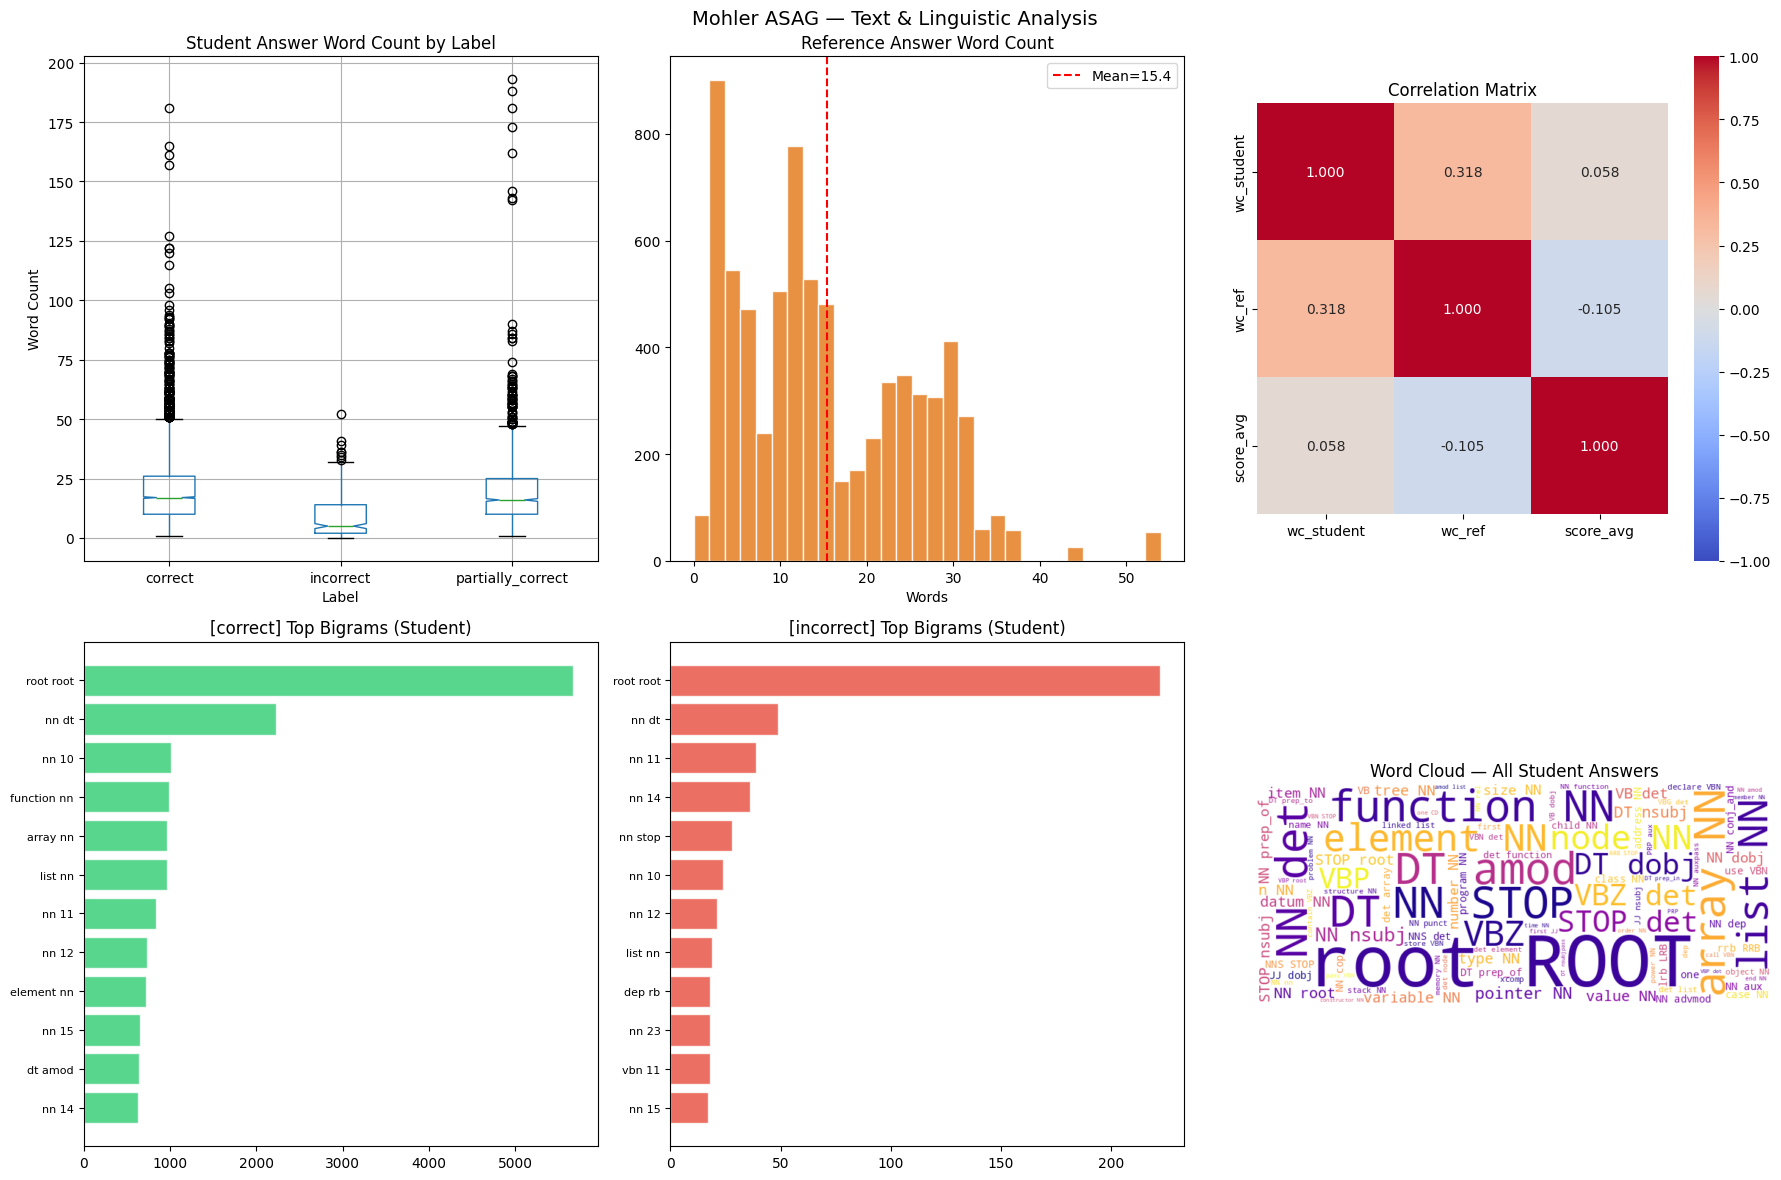

  ✅ Saved → /kaggle/working/eda_outputs/mohler_02_text_ngrams_wc.png


In [18]:
# ============================================================
# CELL 15: [Mohler] TEXT LENGTH + WORD CLOUD + N-GRAM
# ============================================================
df = mohler_raw.copy()
df['label_3way'] = df['score_avg'].map(
    lambda s: 'correct' if float(s if s else 0) >= 4 else
              ('partially_correct' if float(s if s else 0) >= 2 else 'incorrect'))
df['wc_student'] = df['student_answer'].fillna('').apply(lambda x: len(str(x).split()))
# Safe fallback: sau fix CELL 1 sẽ có 'reference_answer'
ref_col = 'reference_answer' if 'reference_answer' in df.columns else 'instructor_answer'
df['wc_ref'] = df[ref_col].fillna('').apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Student answer length by label
df.boxplot(column='wc_student', by='label_3way', ax=axes[0][0], notch=True)
axes[0][0].set_title('Student Answer Word Count by Label')
axes[0][0].set_xlabel('Label')
axes[0][0].set_ylabel('Word Count')

# Reference answer length distribution
axes[0][1].hist(df['wc_ref'].dropna(), bins=30, color='#e67e22', edgecolor='white', alpha=0.85)
axes[0][1].set_title('Reference Answer Word Count')
axes[0][1].set_xlabel('Words')
axes[0][1].axvline(df['wc_ref'].mean(), color='red', linestyle='--',
                    label=f"Mean={df['wc_ref'].mean():.1f}")
axes[0][1].legend()

# Correlation matrix
num_cols = [c for c in ['wc_student','wc_ref','score_avg'] if c in df.columns]
corr_mat = df[num_cols].dropna().corr()
sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[0][2],
            vmin=-1, vmax=1, square=True)
axes[0][2].set_title('Correlation Matrix')

# Top bigrams per label (correct vs incorrect only)
for ax_i, (label, color) in enumerate([('correct','#2ecc71'),('incorrect','#e74c3c')]):
    mask = df['label_3way'] == label
    freq = get_top_ngrams(df.loc[mask,'student_answer'], n=2, top_k=12)
    if freq:
        words, cnts = zip(*freq)
        y_pos = range(len(words))
        axes[1][ax_i].barh(list(y_pos), list(cnts), color=color, alpha=0.8, edgecolor='white')
        axes[1][ax_i].set_yticks(list(y_pos))
        axes[1][ax_i].set_yticklabels(list(words), fontsize=8)
        axes[1][ax_i].invert_yaxis()
        axes[1][ax_i].set_title(f'[{label}] Top Bigrams (Student)')

# Word cloud combined
texts = ' '.join(df['student_answer'].fillna('').astype(str).tolist())
wc = WordCloud(width=700, height=300, background_color='white',
               stopwords=STOP_EN, colormap='plasma', max_words=100,
               random_state=SEED).generate(texts)
axes[1][2].imshow(wc, interpolation='bilinear')
axes[1][2].axis('off')
axes[1][2].set_title('Word Cloud — All Student Answers')

plt.suptitle('Mohler ASAG — Text & Linguistic Analysis', fontsize=14)
plt.tight_layout()
savefig('mohler_02_text_ngrams_wc.png')

In [19]:
# Print all exact column names to spot any discrepancies
print(df.columns.tolist())

['id', 'question', 'reference_answer', 'student_answer', 'score_grader1', 'score_grader2', 'score_avg', 'split', 'config', 'annotations', 'source', 'label_3way', 'wc_student', 'wc_ref']


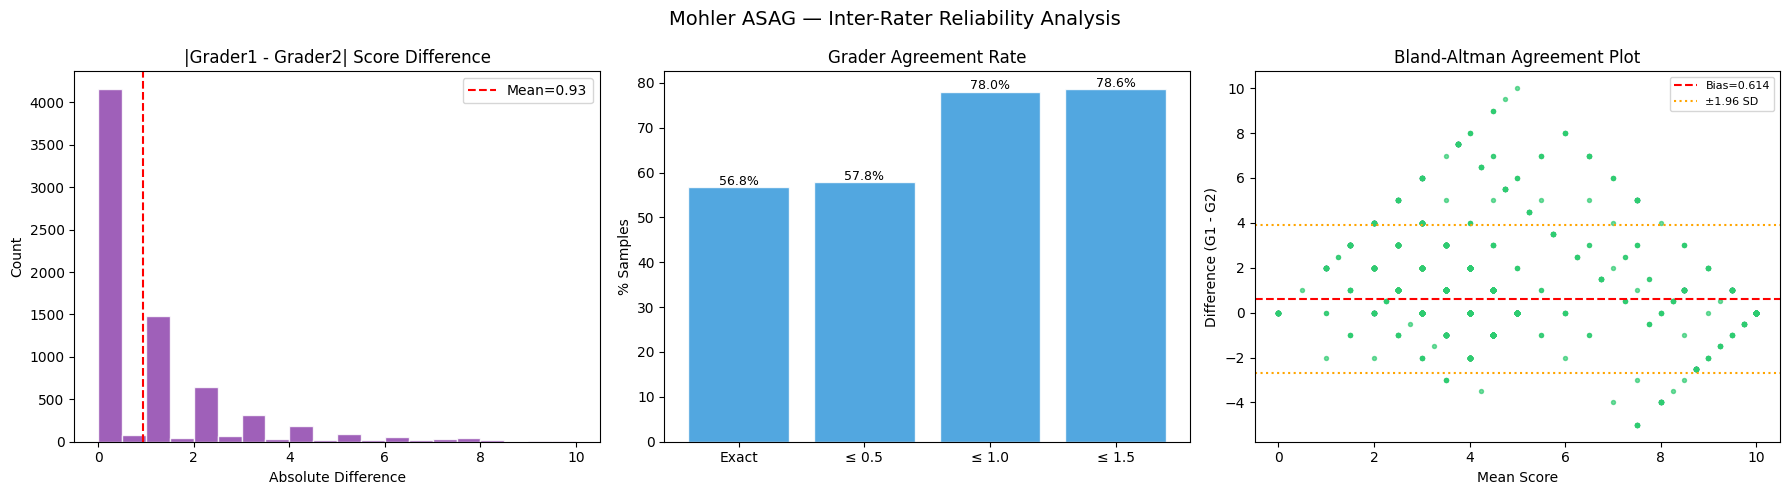

  ✅ Saved → /kaggle/working/eda_outputs/mohler_03_inter_rater.png


In [20]:
# ============================================================
# CELL 16: [Mohler] INTER-RATER AGREEMENT & SCORE CORRELATION
# ============================================================
df = mohler_raw.copy()

# score_grader1/2 đã được rename ở CELL 1 từ score_grader_1/2
if 'score_grader1' in df.columns and 'score_grader2' in df.columns:
    valid = df[['score_grader1','score_grader2']].dropna()
    diff  = (valid['score_grader1'] - valid['score_grader2']).abs()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Score difference distribution
    axes[0].hist(diff, bins=20, color='#8e44ad', edgecolor='white', alpha=0.85)
    axes[0].set_title('|Grader1 - Grader2| Score Difference')
    axes[0].set_xlabel('Absolute Difference')
    axes[0].set_ylabel('Count')
    axes[0].axvline(diff.mean(), color='red', linestyle='--',
                     label=f"Mean={diff.mean():.2f}")
    axes[0].legend()

    # Agreement rate
    agreement_rates = {
        'Exact': (diff == 0).mean() * 100,
        '≤ 0.5': (diff <= 0.5).mean() * 100,
        '≤ 1.0': (diff <= 1.0).mean() * 100,
        '≤ 1.5': (diff <= 1.5).mean() * 100,
    }
    axes[1].bar(list(agreement_rates.keys()), list(agreement_rates.values()),
                 color='#3498db', edgecolor='white', alpha=0.85)
    axes[1].set_title('Grader Agreement Rate')
    axes[1].set_ylabel('% Samples')
    for i, (k, v) in enumerate(agreement_rates.items()):
        axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

    # Bland-Altman plot
    mean_score = (valid['score_grader1'] + valid['score_grader2']) / 2
    diff_signed = valid['score_grader1'] - valid['score_grader2']
    axes[2].scatter(mean_score, diff_signed, alpha=0.3, s=8, color='#2ecc71')
    axes[2].axhline(diff_signed.mean(), color='red', linestyle='--',
                     label=f"Bias={diff_signed.mean():.3f}")
    axes[2].axhline(diff_signed.mean() + 1.96 * diff_signed.std(), color='orange',
                     linestyle=':', label='±1.96 SD')
    axes[2].axhline(diff_signed.mean() - 1.96 * diff_signed.std(), color='orange', linestyle=':')
    axes[2].set_title('Bland-Altman Agreement Plot')
    axes[2].set_xlabel('Mean Score')
    axes[2].set_ylabel('Difference (G1 - G2)')
    axes[2].legend(fontsize=8)

    plt.suptitle('Mohler ASAG — Inter-Rater Reliability Analysis', fontsize=14)
    plt.tight_layout()
    savefig('mohler_03_inter_rater.png')

# OpenStax

📙 OpenStax (Scraping) — Schema Overview
Shape: (129, 38)

Columns: ['sample_id', 'source_dataset', 'original_id', 'question_id', 'domain', 'subdomain', 'difficulty', 'question', 'reference_answer', 'student_answer', 'alternative_reference_answers', 'score_raw', 'score_normalized', 'label_2way', 'label_3way', 'label_5way', 'key_concepts', 'misconception_tags', 'misconception_inventory', 'missing_concepts', 'extra_incorrect_claims', 'feedback_short', 'feedback_detailed', 'feedback_type', 'feedback_tone', 'split', 'is_human_annotated', 'is_synthetic', 'is_adversarial', 'perturbation_type', 'adversarial_variant_of', 'student_answer_style', 'annotation_confidence', 'usable_for_grading', 'usable_for_feedback', 'usable_for_misconception_mining', 'usable_for_robustness_eval', 'source']


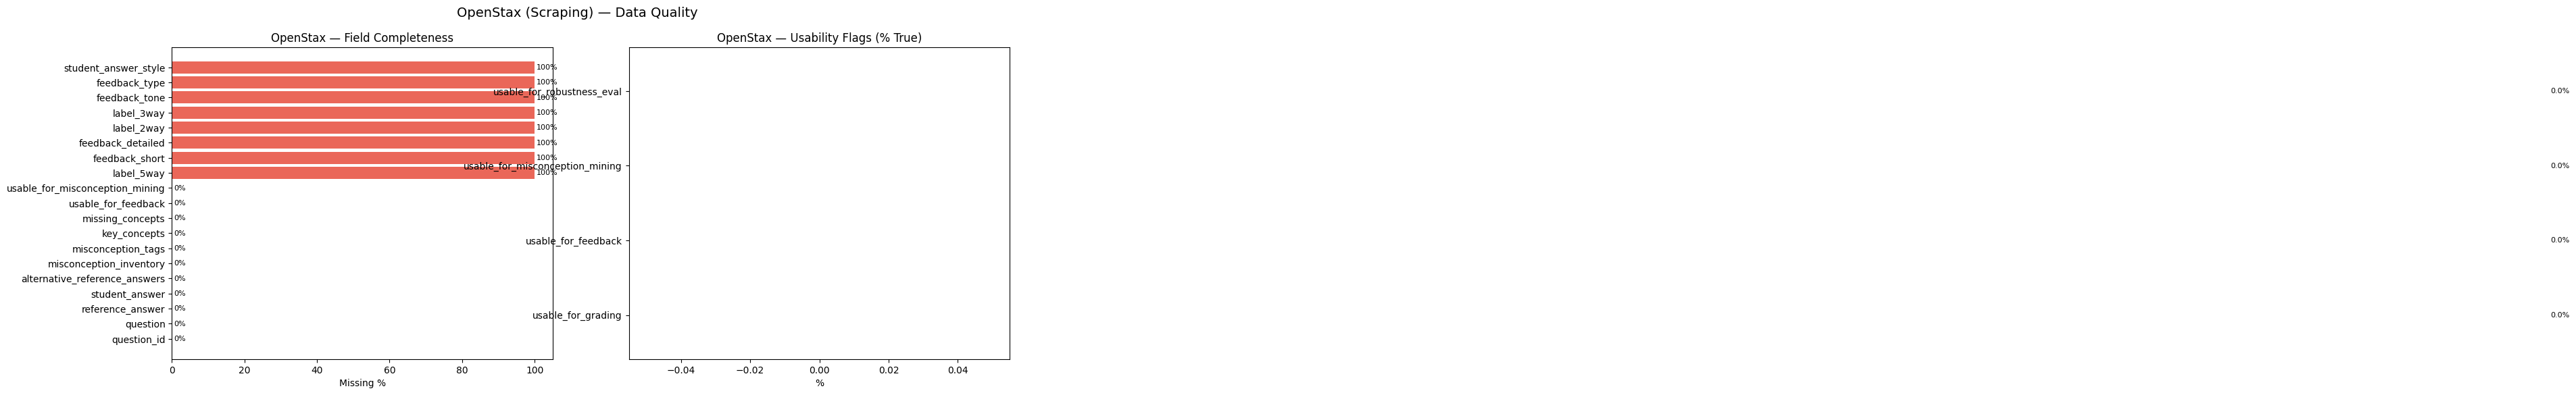

  ✅ Saved → /kaggle/working/eda_outputs/openstax_01_completeness.png


In [21]:
# ============================================================
# CELL 17: [OpenStax] COMPLETENESS & LABEL DISTRIBUTION
# ============================================================
df = openstax_raw.copy()
df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]

# Tìm cột label
label_col = next((c for c in df.columns if 'label_3way' in c or 'label3way' in c), None)
if label_col:
    df['label_3way'] = df[label_col]

print("=" * 60)
print("📙 OpenStax (Scraping) — Schema Overview")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

# Completeness heatmap
text_cols_check = [c for c in df.columns
                   if any(k in c for k in ['answer','question','feedback','label','concept','misconception'])]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

miss_pct = (df[text_cols_check].isnull().mean() * 100).sort_values(ascending=True)
bars = axes[0].barh(miss_pct.index, miss_pct.values,
                     color=['#e74c3c' if v > 50 else '#f39c12' if v > 20 else '#2ecc71'
                            for v in miss_pct.values], alpha=0.85)
axes[0].set_title('OpenStax — Field Completeness')
axes[0].set_xlabel('Missing %')
for i, v in enumerate(miss_pct.values):
    axes[0].text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=8)

# Usability flags
usable_cols = [c for c in df.columns if 'usable' in c.lower()]
if usable_cols:
    usable_rates = (df[usable_cols] == True).mean() * 100
    axes[1].barh(usable_rates.index, usable_rates.values,
                  color='#3498db', alpha=0.85, edgecolor='white')
    axes[1].set_title('OpenStax — Usability Flags (% True)')
    axes[1].set_xlabel('%')
    for i, v in enumerate(usable_rates.values):
        axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
else:
    axes[1].set_visible(False)

plt.suptitle('OpenStax (Scraping) — Data Quality', fontsize=14)
plt.tight_layout()
savefig('openstax_01_completeness.png')

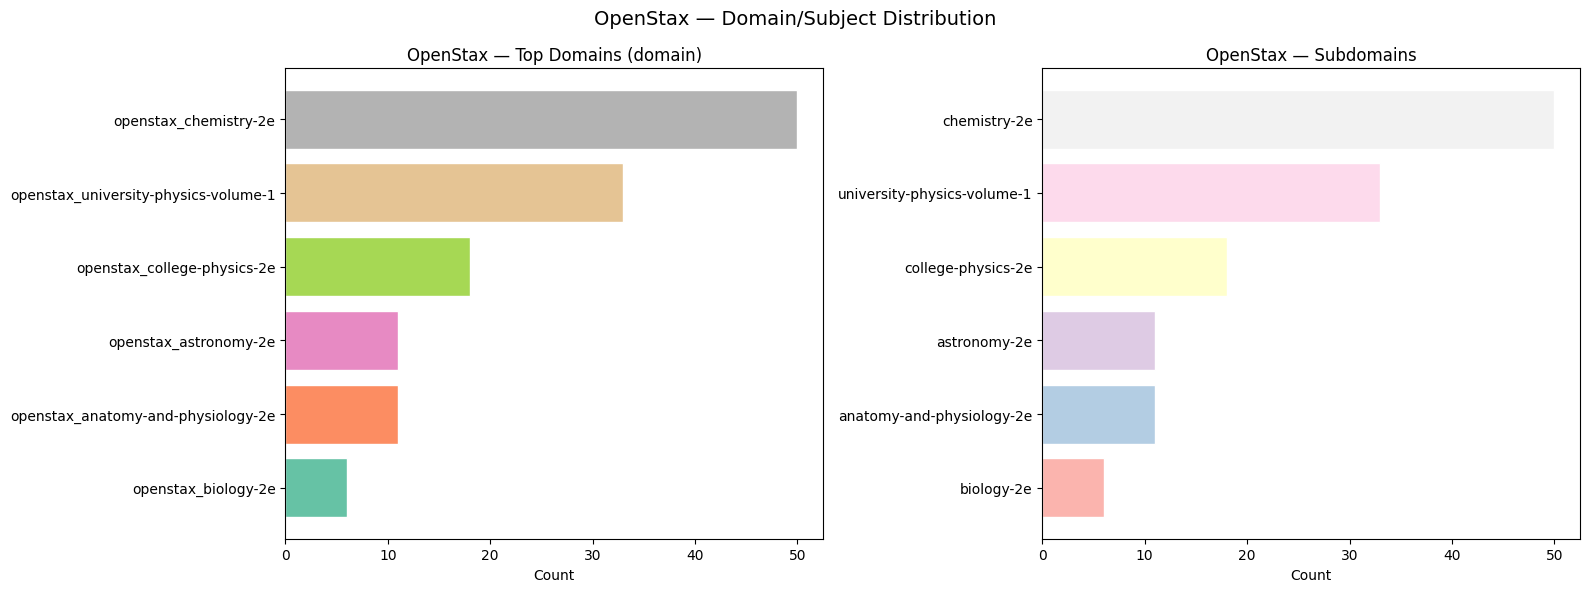

  ✅ Saved → /kaggle/working/eda_outputs/openstax_02_domain_distribution.png


In [22]:
# ============================================================
# CELL 18: [OpenStax] DOMAIN / SUBJECT DISTRIBUTION
# ============================================================
df = openstax_raw.copy()
df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]

domain_col = next((c for c in df.columns if 'domain' in c), None)
subdom_col = next((c for c in df.columns if 'subdomain' in c or 'subject' in c), None)

if domain_col:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    dc = df[domain_col].fillna('Unknown').value_counts().head(20)
    axes[0].barh(dc.index[::-1], dc.values[::-1],
                  color=plt.cm.Set2(np.linspace(0, 1, len(dc))), edgecolor='white')
    axes[0].set_title(f'OpenStax — Top Domains ({domain_col})')
    axes[0].set_xlabel('Count')

    if subdom_col:
        sc = df[subdom_col].fillna('Unknown').value_counts().head(15)
        axes[1].barh(sc.index[::-1], sc.values[::-1],
                      color=plt.cm.Pastel1(np.linspace(0, 1, len(sc))), edgecolor='white')
        axes[1].set_title(f'OpenStax — Subdomains')
        axes[1].set_xlabel('Count')
    else:
        axes[1].set_visible(False)

    plt.suptitle('OpenStax — Domain/Subject Distribution', fontsize=14)
    plt.tight_layout()
    savefig('openstax_02_domain_distribution.png')

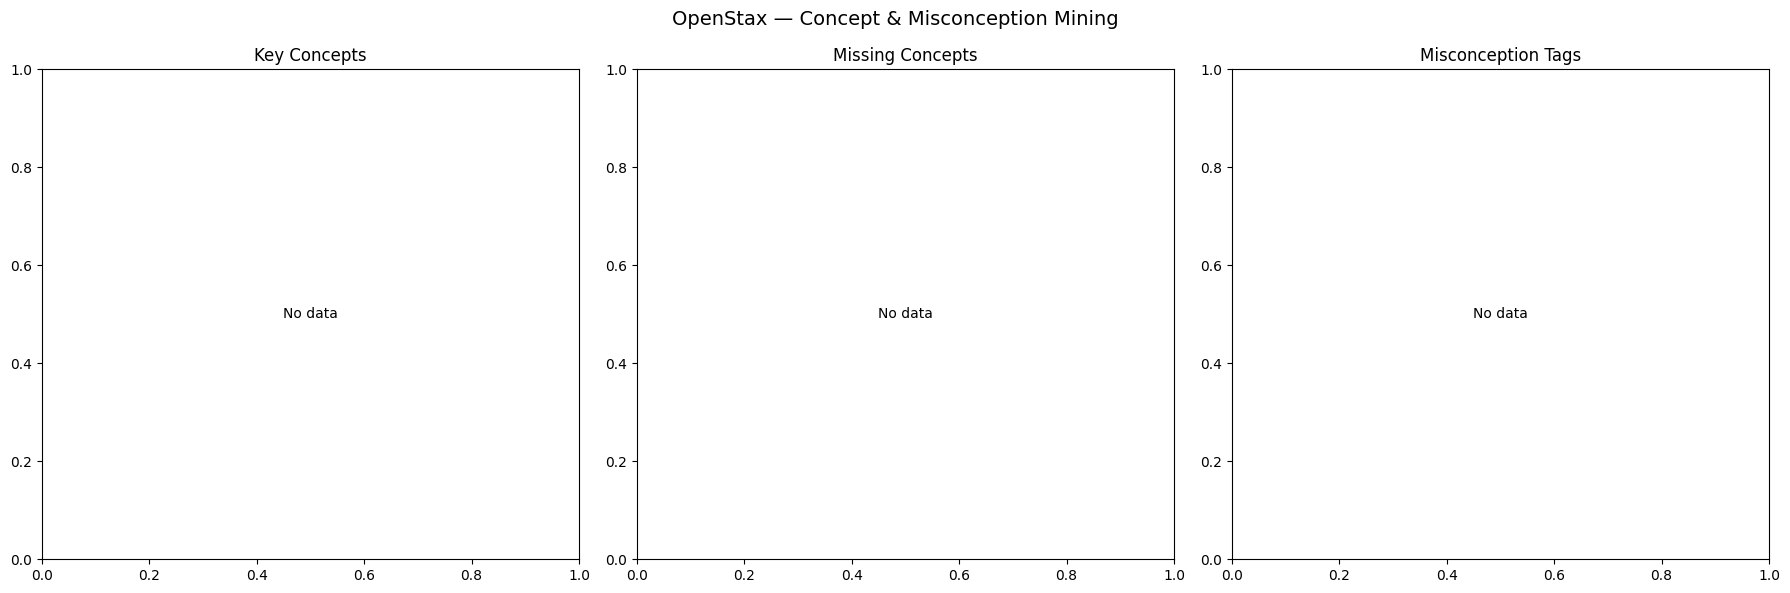

  ✅ Saved → /kaggle/working/eda_outputs/openstax_03_concept_misconception.png
Plotted 0/3 columns successfully


In [23]:
# ============================================================
# CELL 19: [OpenStax] CONCEPT & MISCONCEPTION MINING
# ============================================================
df = openstax_raw.copy()
df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]

def parse_list_col(col_val):
    if col_val is None or (isinstance(col_val, float) and pd.isna(col_val)):
        return []
    if isinstance(col_val, list): return col_val
    s = str(col_val).strip()
    if not s or s in ['[]','nan','None']:  return []
    try:
        parsed = json.loads(s.replace("'",'"'))
        return parsed if isinstance(parsed, list) else [s]
    except:
        return [p.strip() for p in re.split(r'[,;|]+', s) if p.strip()]

concept_col  = next((c for c in df.columns if 'keyconcept' in c or 'key_concept' in c), None)
miscon_col   = next((c for c in df.columns if 'misconception' in c and 'tag' in c), None)
missing_col  = next((c for c in df.columns if 'missing' in c and 'concept' in c), None)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plotted = 0

for ax, col, title, color in [
    (axes[0], concept_col,  'Key Concepts',        '#3498db'),
    (axes[1], missing_col,  'Missing Concepts',    '#e74c3c'),
    (axes[2], miscon_col,   'Misconception Tags',  '#9b59b6'),
]:
    if col is None or col not in df.columns:
        ax.text(0.5, 0.5, 'Column not found', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue
    all_items = []
    for v in df[col].dropna():
        all_items.extend(parse_list_col(v))
    if not all_items:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue
    top = Counter(all_items).most_common(15)
    words, cnts = zip(*top)
    y_pos = range(len(words))
    ax.barh(list(y_pos), list(cnts), color=color, alpha=0.8, edgecolor='white')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(list(words), fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f'OpenStax — Top 15 {title}')
    ax.set_xlabel('Frequency')
    plotted += 1

plt.suptitle('OpenStax — Concept & Misconception Mining', fontsize=14)
plt.tight_layout()
savefig('openstax_03_concept_misconception.png')
print(f"Plotted {plotted}/3 columns successfully")

# LLM-Generated

📕 LLM Generated — Overview
Shape: (10000, 38)

Label distribution:
label_3way
incorrect    6640
correct      3360
Name: count, dtype: int64

Annotation confidence stats:
count    10000.000
mean         0.908
std          0.043
min          0.830
25%          0.880
50%          0.910
75%          0.940
max          0.970
Name: annotation_confidence, dtype: float64


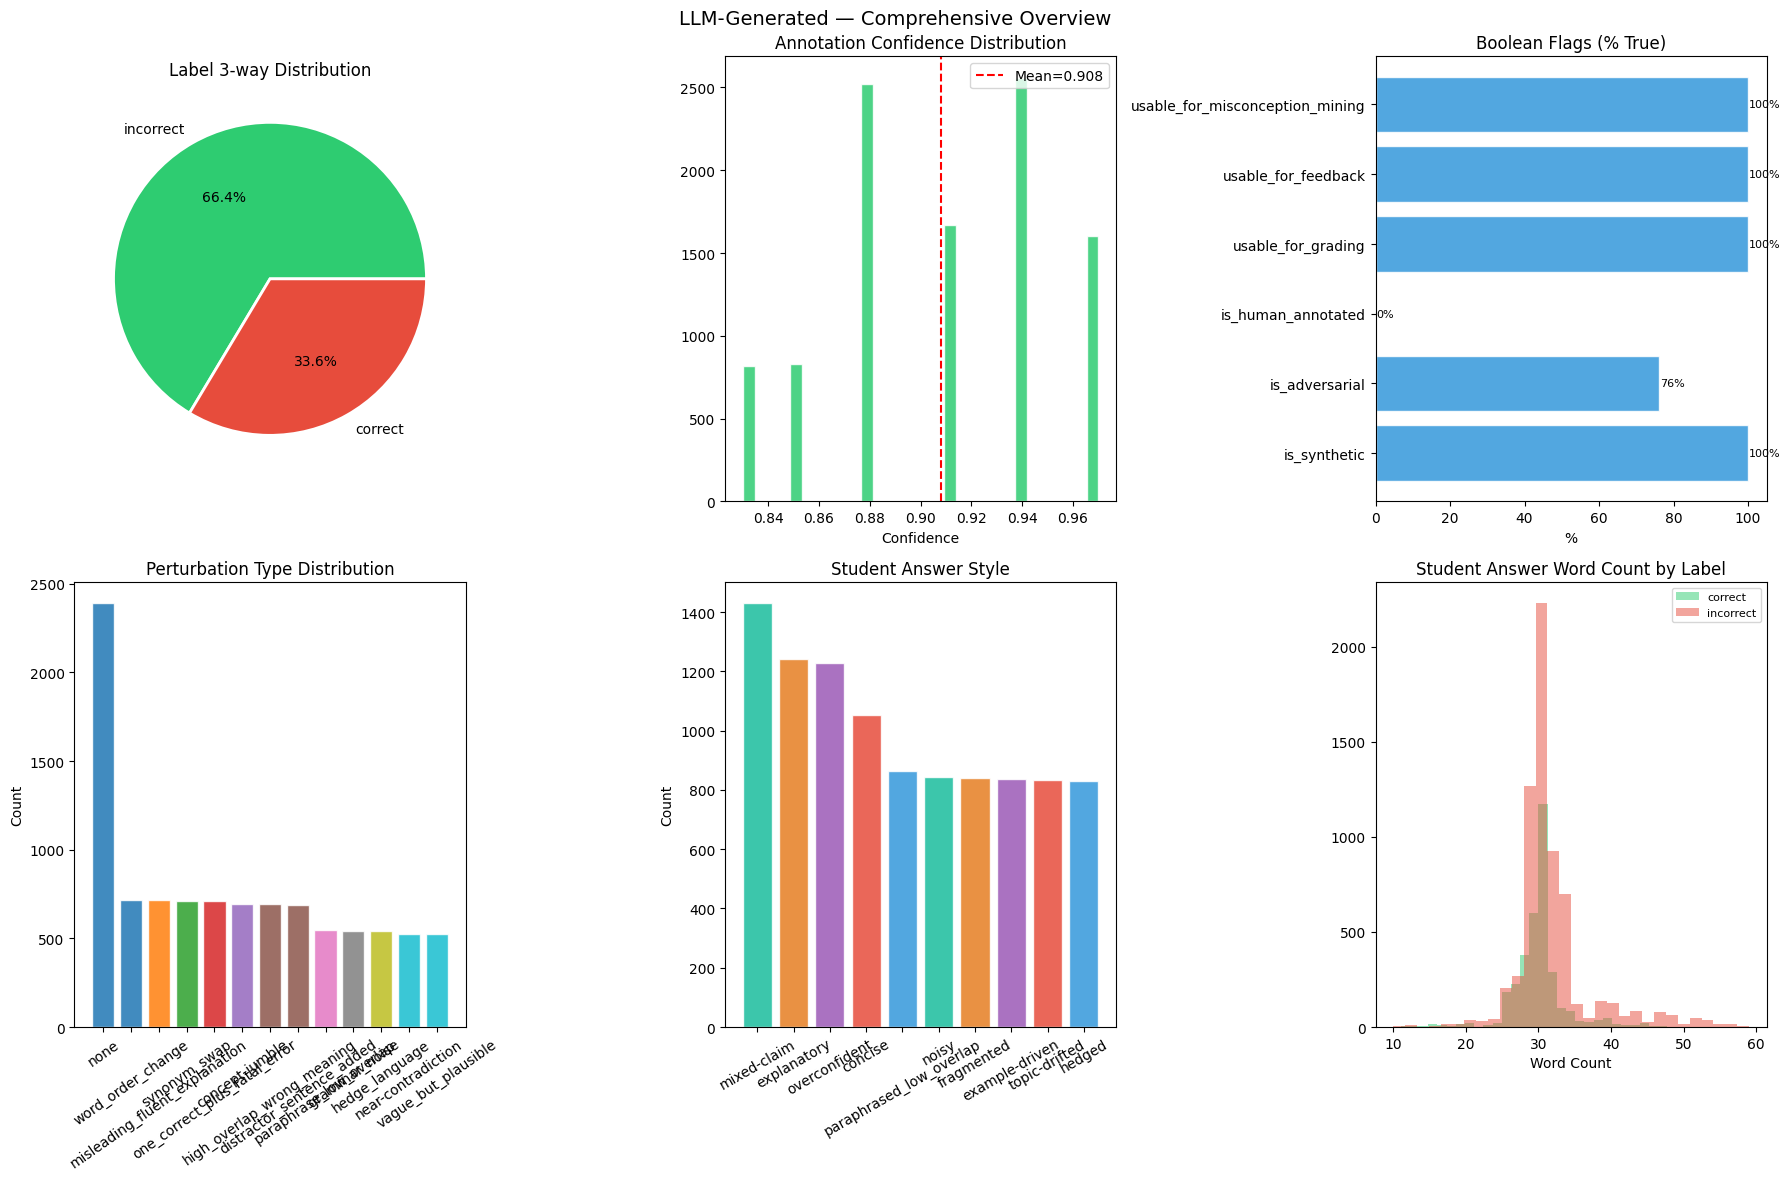

  ✅ Saved → /kaggle/working/eda_outputs/llm_01_overview.png


In [24]:
# ============================================================
# CELL 20: [LLM-Generated] THỐNG KÊ & ĐÁNH GIÁ CHẤT LƯỢNG
# ============================================================
df = llm_raw.copy()
df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]

label_col = next((c for c in df.columns if 'label_3way' in c or 'label3way' in c), None)
conf_col  = next((c for c in df.columns if 'confidence' in c), None)

print("=" * 60)
print("📕 LLM Generated — Overview")
print("=" * 60)
print(f"Shape: {df.shape}")
if label_col:
    print(f"\nLabel distribution:\n{df[label_col].value_counts()}")
if conf_col:
    print(f"\nAnnotation confidence stats:\n{pd.to_numeric(df[conf_col], errors='coerce').describe().round(3)}")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Label distribution
if label_col:
    counts = df[label_col].value_counts()
    axes[0][0].pie(counts, labels=counts.index, autopct='%1.1f%%',
                    colors=['#2ecc71','#e74c3c','#3498db','#f39c12'][:len(counts)],
                    wedgeprops={'edgecolor':'white','linewidth':2})
    axes[0][0].set_title('Label 3-way Distribution')

# Annotation confidence
if conf_col:
    conf_series = pd.to_numeric(df[conf_col], errors='coerce').dropna()
    axes[0][1].hist(conf_series, bins=30, color='#2ecc71', edgecolor='white', alpha=0.85)
    axes[0][1].set_title('Annotation Confidence Distribution')
    axes[0][1].set_xlabel('Confidence')
    axes[0][1].axvline(conf_series.mean(), color='red', linestyle='--',
                        label=f"Mean={conf_series.mean():.3f}")
    axes[0][1].legend()

# Synthetic & Adversarial breakdown
bool_cols = ['is_synthetic','is_adversarial','is_human_annotated',
             'usable_for_grading','usable_for_feedback','usable_for_misconception_mining']
bool_cols = [c for c in bool_cols if c in df.columns]
if bool_cols:
    rates = {}
    for c in bool_cols:
        rates[c] = (df[c].astype(str).str.lower().isin(['true','1','yes'])).mean() * 100
    axes[0][2].barh(list(rates.keys()), list(rates.values()),
                     color='#3498db', alpha=0.85, edgecolor='white')
    axes[0][2].set_title('Boolean Flags (% True)')
    axes[0][2].set_xlabel('%')
    for i, v in enumerate(rates.values()):
        axes[0][2].text(v + 0.3, i, f'{v:.0f}%', va='center', fontsize=8)

# Perturbation type distribution
pert_col = next((c for c in df.columns if 'perturbation' in c and 'type' in c), None)
if pert_col:
    pert_counts = df[pert_col].fillna('none').value_counts()
    axes[1][0].bar(pert_counts.index, pert_counts.values,
                    color=plt.cm.tab10(np.linspace(0,1,len(pert_counts))), edgecolor='white', alpha=0.85)
    axes[1][0].set_title('Perturbation Type Distribution')
    axes[1][0].tick_params(axis='x', rotation=35)
    axes[1][0].set_ylabel('Count')

# Student answer style
style_col = next((c for c in df.columns if 'style' in c), None)
if style_col:
    sc = df[style_col].fillna('unknown').value_counts()
    axes[1][1].bar(sc.index, sc.values,
                    color=['#1abc9c','#e67e22','#9b59b6','#e74c3c','#3498db'][:len(sc)],
                    edgecolor='white', alpha=0.85)
    axes[1][1].set_title('Student Answer Style')
    axes[1][1].tick_params(axis='x', rotation=30)
    axes[1][1].set_ylabel('Count')

# Word count distribution
student_col = next((c for c in df.columns if 'student_answer' in c or 'studentanswer' in c), None)
if student_col:
    df['wc'] = df[student_col].fillna('').apply(lambda x: len(str(x).split()))
    if label_col:
        for label, color in [
            (df[label_col].unique()[0] if len(df[label_col].unique())>0 else '', '#2ecc71'),
        ]:
            pass
        for label, color in zip(['correct','partially_correct','incorrect'],
                                  ['#2ecc71','#3498db','#e74c3c']):
            mask = df[label_col] == label
            if mask.any():
                axes[1][2].hist(df.loc[mask,'wc'], bins=30, alpha=0.5, color=color, label=label)
        axes[1][2].set_title('Student Answer Word Count by Label')
        axes[1][2].set_xlabel('Word Count')
        axes[1][2].legend(fontsize=8)
    else:
        axes[1][2].hist(df['wc'], bins=30, color='#9b59b6', edgecolor='white', alpha=0.85)
        axes[1][2].set_title('Student Answer Word Count')

plt.suptitle('LLM-Generated — Comprehensive Overview', fontsize=14)
plt.tight_layout()
savefig('llm_01_overview.png')

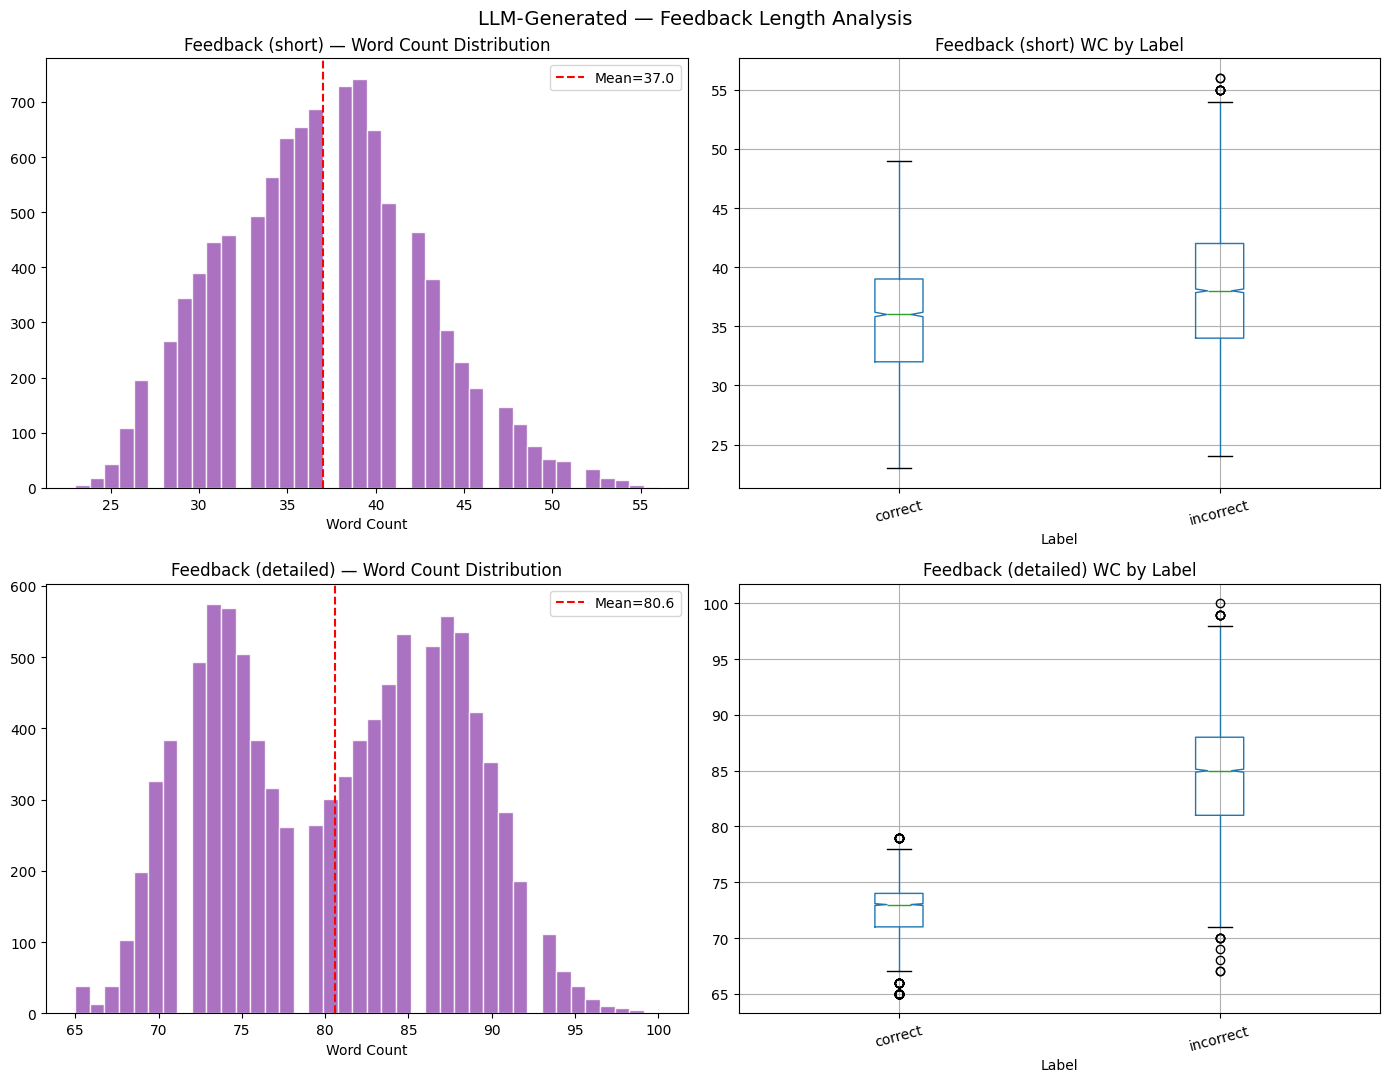

  ✅ Saved → /kaggle/working/eda_outputs/llm_02_feedback_length.png


In [25]:
# ============================================================
# CELL 21: [LLM-Generated] FEEDBACK QUALITY ANALYSIS
# ============================================================
df = llm_raw.copy()
df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]

feedback_cols = {
    'short': next((c for c in df.columns if 'feedback_short' in c or 'feedbackshort' in c), None),
    'detailed': next((c for c in df.columns if 'feedback_detailed' in c or 'feedbackdetailed' in c), None),
}
label_col = next((c for c in df.columns if 'label_3way' in c or 'label3way' in c), None)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax_pair, (fb_type, col) in zip([(axes[0][0], axes[0][1]), (axes[1][0], axes[1][1])],
                                     feedback_cols.items()):
    ax_len, ax_box = ax_pair
    if col is None or col not in df.columns:
        ax_len.set_visible(False); ax_box.set_visible(False)
        continue
    df[f'fb_{fb_type}_wc'] = df[col].fillna('').apply(lambda x: len(str(x).split()))
    df[f'fb_{fb_type}_has'] = df[col].notna() & (df[col].astype(str).str.len() > 5)

    ax_len.hist(df.loc[df[f'fb_{fb_type}_has'], f'fb_{fb_type}_wc'],
                 bins=40, color='#9b59b6', edgecolor='white', alpha=0.85)
    ax_len.set_title(f'Feedback ({fb_type}) — Word Count Distribution')
    ax_len.set_xlabel('Word Count')
    ax_len.axvline(df[f'fb_{fb_type}_wc'].mean(), color='red', linestyle='--',
                    label=f"Mean={df[f'fb_{fb_type}_wc'].mean():.1f}")
    ax_len.legend()

    if label_col:
        df.boxplot(column=f'fb_{fb_type}_wc', by=label_col, ax=ax_box, notch=True)
        ax_box.set_title(f'Feedback ({fb_type}) WC by Label')
        ax_box.set_xlabel('Label')
        ax_box.tick_params(axis='x', rotation=15)

plt.suptitle('LLM-Generated — Feedback Length Analysis', fontsize=14)
plt.tight_layout()
savefig('llm_02_feedback_length.png')

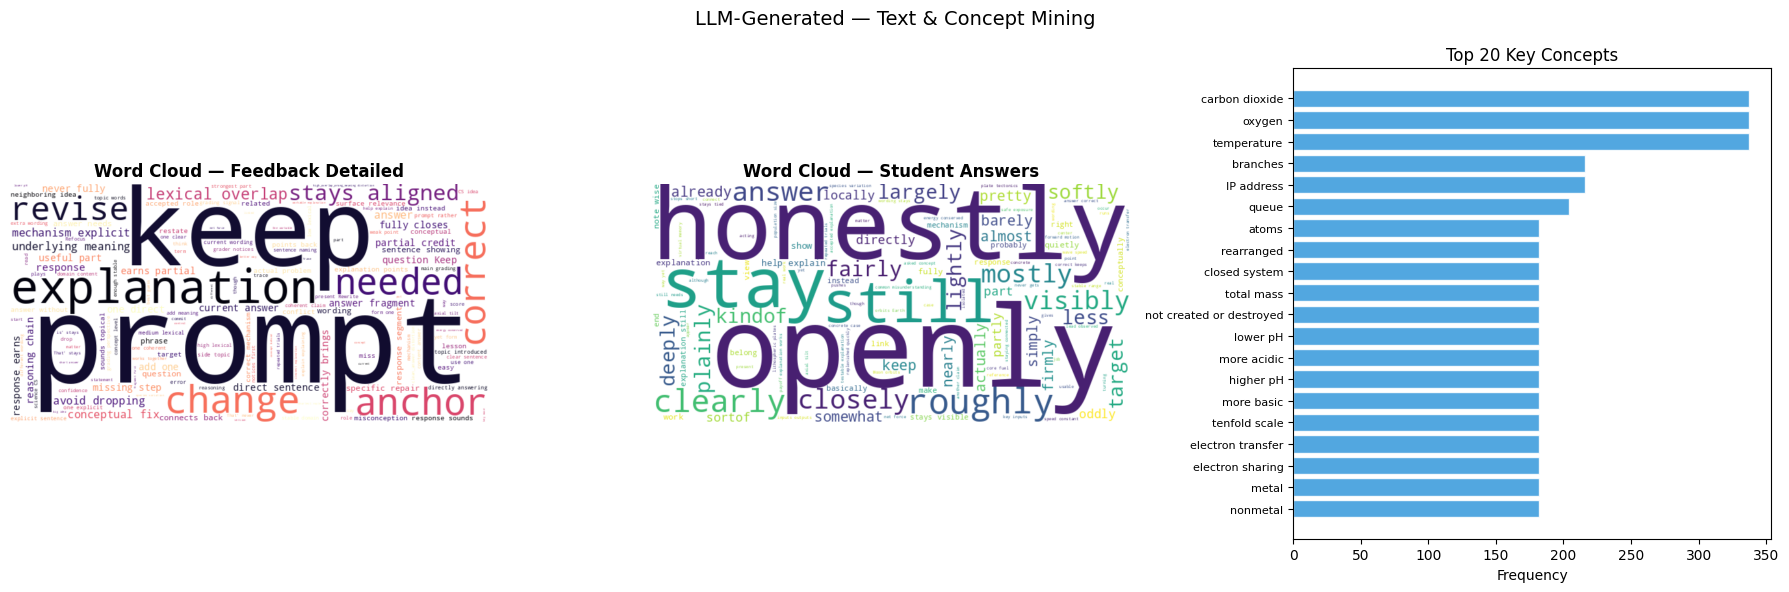

  ✅ Saved → /kaggle/working/eda_outputs/llm_03_wordcloud_concepts.png


In [26]:
# ============================================================
# CELL 22: [LLM-Generated] WORD CLOUD FEEDBACK + N-GRAM CONCEPTS
# ============================================================
df = llm_raw.copy()
df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]

feedback_col = next((c for c in df.columns if 'feedback_detailed' in c or 'feedbackdetailed' in c), None)
concept_col  = next((c for c in df.columns if 'keyconcept' in c or 'key_concept' in c), None)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Feedback word cloud
if feedback_col and feedback_col in df.columns:
    texts = ' '.join(df[feedback_col].fillna('').astype(str).tolist())
    wc = WordCloud(width=700, height=350, background_color='white',
                   stopwords=STOP_EN, colormap='magma', max_words=150,
                   random_state=SEED).generate(texts)
    axes[0].imshow(wc, interpolation='bilinear')
    axes[0].axis('off')
    axes[0].set_title('Word Cloud — Feedback Detailed', fontweight='bold')

# Student answer word cloud
student_col = next((c for c in df.columns if 'student_answer' in c or 'studentanswer' in c), None)
if student_col:
    texts2 = ' '.join(df[student_col].fillna('').astype(str).tolist())
    wc2 = WordCloud(width=700, height=350, background_color='white',
                    stopwords=STOP_EN, colormap='viridis', max_words=120,
                    random_state=SEED).generate(texts2)
    axes[1].imshow(wc2, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('Word Cloud — Student Answers', fontweight='bold')

# Key concepts frequency
if concept_col and concept_col in df.columns:
    all_concepts = []
    for v in df[concept_col].dropna():
        all_concepts.extend(parse_list_col(v))
    if all_concepts:
        top_c = Counter(all_concepts).most_common(20)
        words, cnts = zip(*top_c)
        y_pos = range(len(words))
        axes[2].barh(list(y_pos), list(cnts), color='#3498db', alpha=0.85, edgecolor='white')
        axes[2].set_yticks(list(y_pos))
        axes[2].set_yticklabels(list(words), fontsize=8)
        axes[2].invert_yaxis()
        axes[2].set_title('Top 20 Key Concepts')
        axes[2].set_xlabel('Frequency')
    else:
        axes[2].set_visible(False)
else:
    axes[2].set_visible(False)

plt.suptitle('LLM-Generated — Text & Concept Mining', fontsize=14)
plt.tight_layout()
savefig('llm_03_wordcloud_concepts.png')

# UNIFIED — SO SÁNH 4 DATASETS SONG SONG

✅ Unified dataset: (28291, 7)
               wc_student  wc_ref
source                           
LLM_Generated       31.14   22.38
Mohler              19.46   15.36
OpenStax             0.00   12.97
SciEntsBank         12.03   16.05


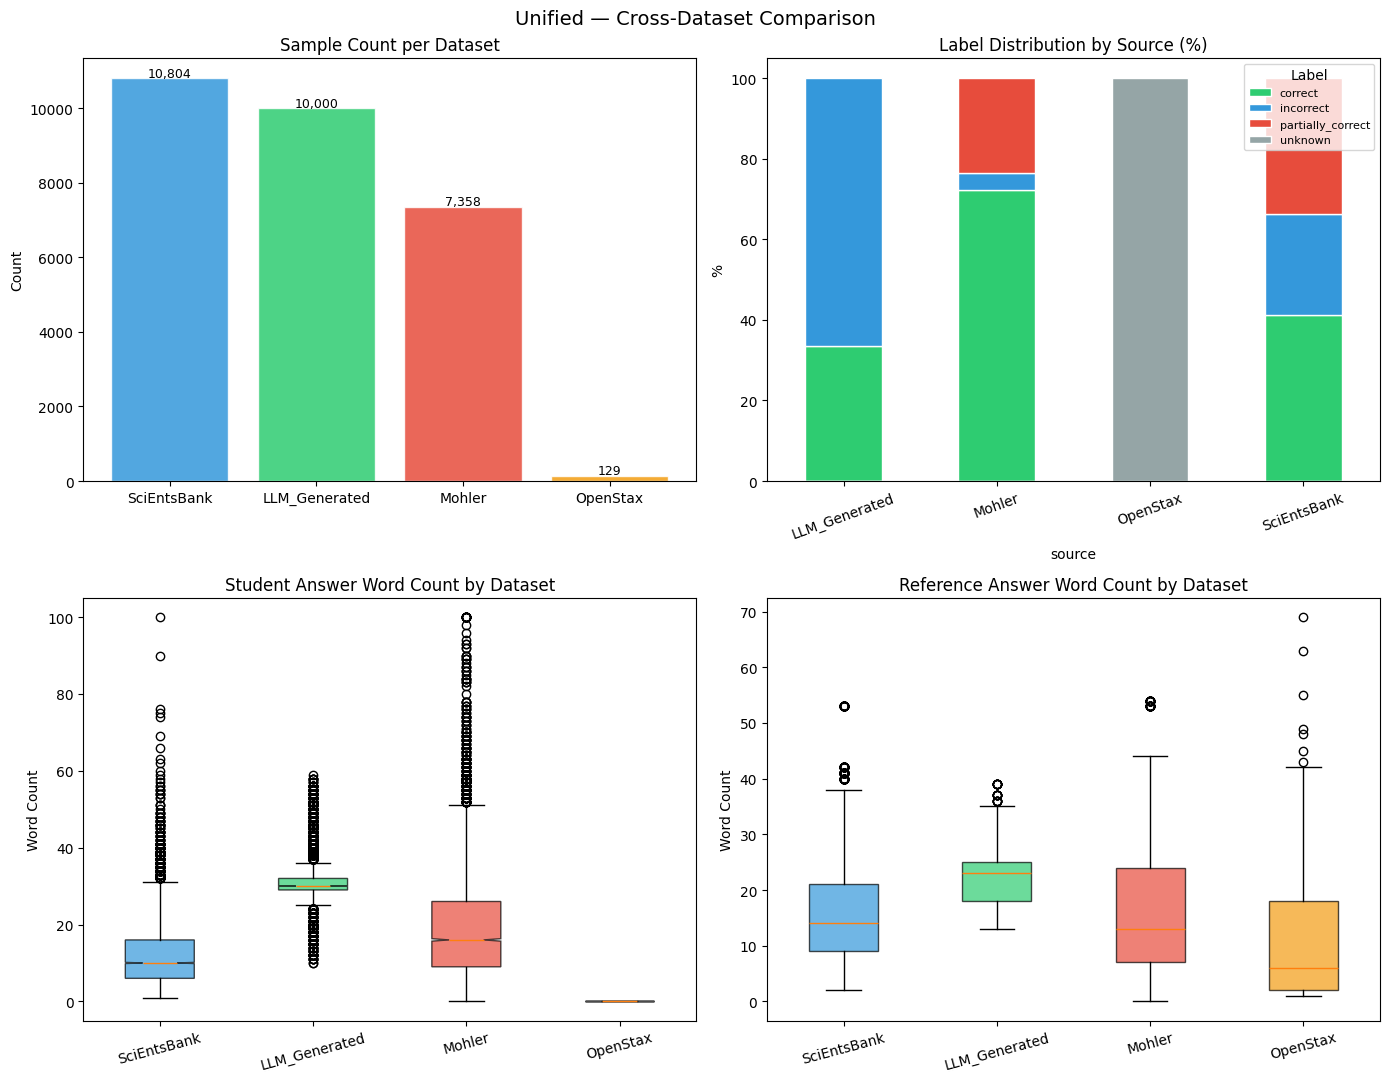

  ✅ Saved → /kaggle/working/eda_outputs/unified_01_cross_comparison.png


In [27]:
# ============================================================
# CELL 23: UNIFIED — SO SÁNH 4 DATASETS SONG SONG
# ============================================================

# Chuẩn hóa sang unified schema nhỏ gọn
def to_mini_unified(df, source, student_col, ref_col, q_col, label_col):
    out = pd.DataFrame()
    out['student_answer']   = df.get(student_col,  pd.Series(dtype=str)).fillna('')
    out['reference_answer'] = df.get(ref_col,       pd.Series(dtype=str)).fillna('')
    out['question']         = df.get(q_col,         pd.Series(dtype=str)).fillna('')
    out['label_3way']       = df.get(label_col,     pd.Series(dtype=str)).fillna('unknown')
    out['source']           = source
    out['wc_student'] = out['student_answer'].apply(lambda x: len(str(x).split()))
    out['wc_ref']     = out['reference_answer'].apply(lambda x: len(str(x).split()))
    return out

scib_r = scib_raw.copy()
scib_r['label_3way'] = scib_r['label_raw'].map(
    {0:'correct',1:'partially_correct',2:'partially_correct',3:'incorrect',4:'incorrect'})

mohler_r = mohler_raw.copy()
mohler_r['label_3way'] = mohler_r['score_avg'].map(
    lambda s: 'correct' if float(s if pd.notnull(s) else 0) >= 4 else
              'partially_correct' if float(s if pd.notnull(s) else 0) >= 2 else 'incorrect')

openstax_cols = {c.strip().lower().replace(' ','_'): c for c in openstax_raw.columns}
openstax_r = openstax_raw.rename(columns=lambda c: c.strip().lower().replace(' ','_'))

llm_cols_map = {c.strip().lower().replace(' ','_'): c for c in llm_raw.columns}
llm_r = llm_raw.rename(columns=lambda c: c.strip().lower().replace(' ','_'))

mini_scib  = to_mini_unified(scib_r, 'SciEntsBank','student_answer','reference_answer','question','label_3way')
# Sau khi rename, mohler_r có cột 'reference_answer'
mini_mohler= to_mini_unified(mohler_r,'Mohler','student_answer','reference_answer','question','label_3way')

openstax_student = next((c for c in openstax_r.columns if 'student_answer' in c), 'student_answer')
openstax_ref     = next((c for c in openstax_r.columns if 'reference_answer' in c), 'reference_answer')
openstax_label   = next((c for c in openstax_r.columns if 'label_3way' in c or 'label3way' in c), 'label_3way')
mini_openstax = to_mini_unified(openstax_r,'OpenStax', openstax_student, openstax_ref,'question', openstax_label)

llm_student = next((c for c in llm_r.columns if 'student_answer' in c), 'student_answer')
llm_ref     = next((c for c in llm_r.columns if 'reference_answer' in c), 'reference_answer')
llm_label   = next((c for c in llm_r.columns if 'label_3way' in c or 'label3way' in c), 'label_3way')
mini_llm    = to_mini_unified(llm_r,'LLM_Generated', llm_student, llm_ref,'question', llm_label)

unified = pd.concat([mini_scib, mini_mohler, mini_openstax, mini_llm], ignore_index=True)
print(f"✅ Unified dataset: {unified.shape}")
print(unified.groupby('source')[['wc_student','wc_ref']].mean().round(2))

# ── Plot 1: Sample count per source ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

src_counts = unified['source'].value_counts()
colors_src = ['#3498db','#2ecc71','#e74c3c','#f39c12']

axes[0][0].bar(src_counts.index, src_counts.values, color=colors_src, edgecolor='white', alpha=0.85)
axes[0][0].set_title('Sample Count per Dataset')
axes[0][0].set_ylabel('Count')
for i, v in enumerate(src_counts.values):
    axes[0][0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# ── Plot 2: Label distribution per source ───────────────────
src_label = unified.groupby(['source','label_3way']).size().unstack(fill_value=0)
src_label_pct = src_label.div(src_label.sum(axis=1), axis=0) * 100
src_label_pct.plot(kind='bar', ax=axes[0][1],
                    color=['#2ecc71','#3498db','#e74c3c','#95a5a6'][:len(src_label_pct.columns)],
                    stacked=True, edgecolor='white', rot=20)
axes[0][1].set_title('Label Distribution by Source (%)')
axes[0][1].set_ylabel('%')
axes[0][1].legend(title='Label', fontsize=8, loc='upper right')

# ── Plot 3: Word count boxplot student_answer ────────────────
data_for_box = [unified[unified['source']==s]['wc_student'].clip(0,100).dropna().values
                for s in src_counts.index]
bp = axes[1][0].boxplot(data_for_box, labels=src_counts.index, patch_artist=True, notch=True)
for patch, c in zip(bp['boxes'], colors_src):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1][0].set_title('Student Answer Word Count by Dataset')
axes[1][0].set_ylabel('Word Count')
axes[1][0].tick_params(axis='x', rotation=15)

# ── Plot 4: Reference answer word count ─────────────────────
data_for_box2 = [unified[unified['source']==s]['wc_ref'].clip(0,200).dropna().values
                  for s in src_counts.index]
bp2 = axes[1][1].boxplot(data_for_box2, labels=src_counts.index, patch_artist=True)
for patch, c in zip(bp2['boxes'], colors_src):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1][1].set_title('Reference Answer Word Count by Dataset')
axes[1][1].set_ylabel('Word Count')
axes[1][1].tick_params(axis='x', rotation=15)

plt.suptitle('Unified — Cross-Dataset Comparison', fontsize=14)
plt.tight_layout()
savefig('unified_01_cross_comparison.png')

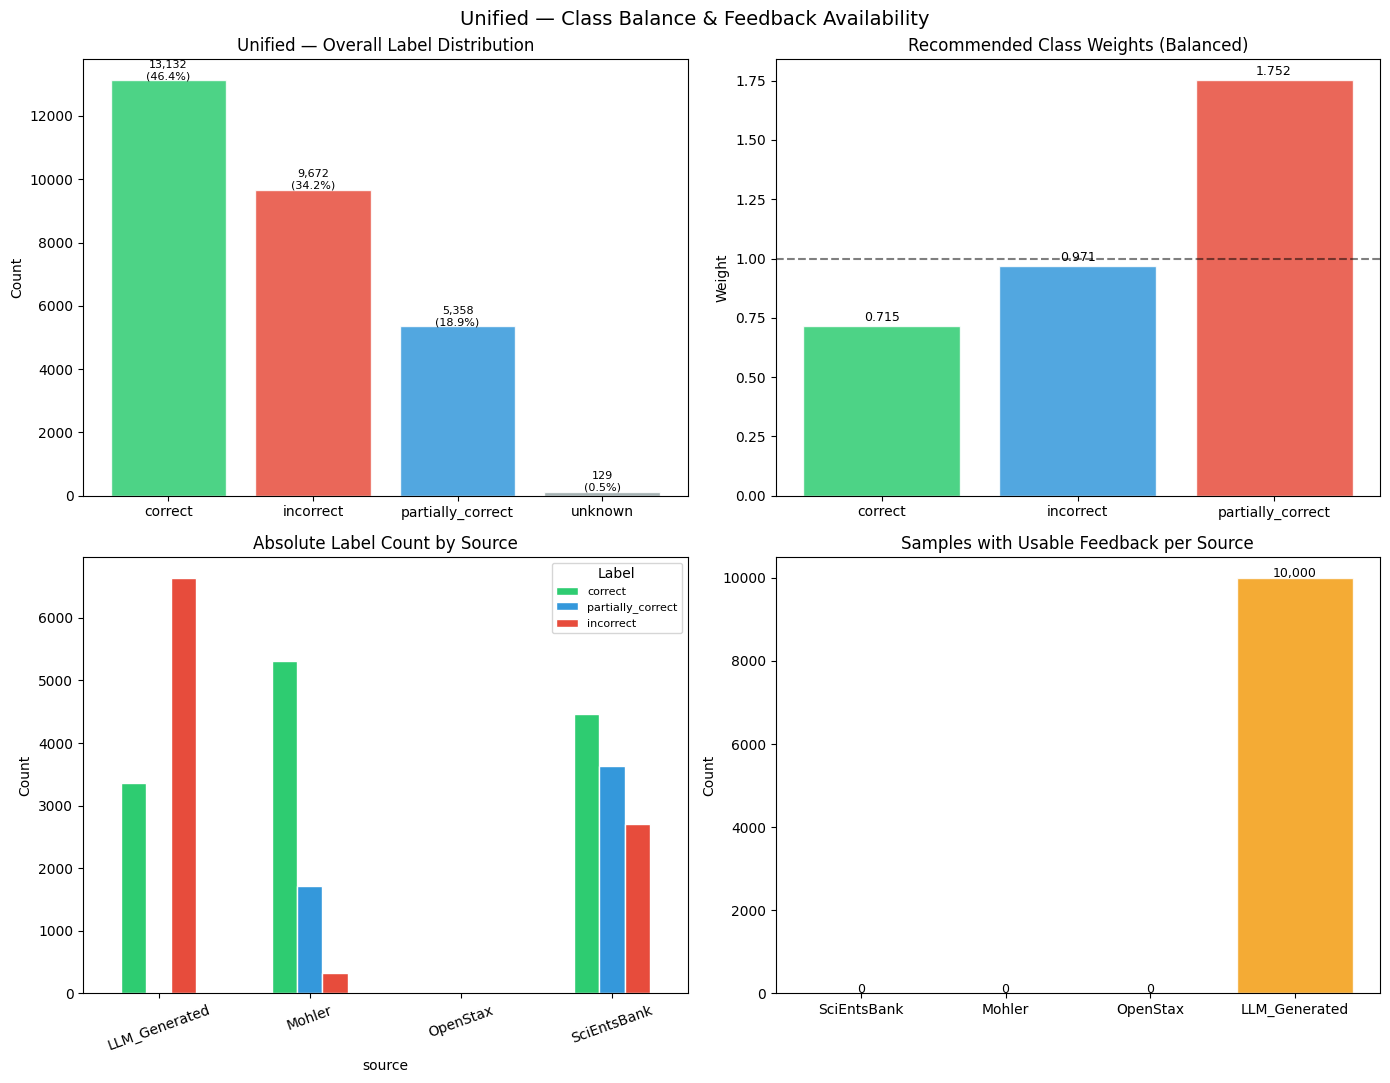

  ✅ Saved → /kaggle/working/eda_outputs/unified_02_label_imbalance.png
Class weights: {'correct': np.float64(0.7148441466138694), 'incorrect': np.float64(0.9705679625034463), 'partially_correct': np.float64(1.7520218987184273)}


In [28]:
# ============================================================
# CELL 24: UNIFIED — LABEL IMBALANCE & CLASS WEIGHT ANALYSIS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Overall label distribution
overall = unified['label_3way'].value_counts()
axes[0][0].bar(overall.index, overall.values,
                color=['#2ecc71','#e74c3c','#3498db','#95a5a6'][:len(overall)],
                edgecolor='white', alpha=0.85)
axes[0][0].set_title('Unified — Overall Label Distribution')
axes[0][0].set_ylabel('Count')
for i, (label, cnt) in enumerate(overall.items()):
    axes[0][0].text(i, cnt + 30, f'{cnt:,}\n({cnt/len(unified)*100:.1f}%)',
                     ha='center', fontsize=8)

# Class weight recommendation
from sklearn.utils.class_weight import compute_class_weight
labels_valid = unified[unified['label_3way'].isin(['correct','partially_correct','incorrect'])]
class_weights = compute_class_weight('balanced',
                                      classes=np.unique(labels_valid['label_3way']),
                                      y=labels_valid['label_3way'].values)
cw_dict = dict(zip(np.unique(labels_valid['label_3way']), class_weights))
axes[0][1].bar(list(cw_dict.keys()), list(cw_dict.values()),
                color=['#2ecc71','#3498db','#e74c3c'], edgecolor='white', alpha=0.85)
axes[0][1].set_title('Recommended Class Weights (Balanced)')
axes[0][1].set_ylabel('Weight')
axes[0][1].axhline(1.0, color='black', linestyle='--', alpha=0.5, label='Weight=1')
for i, (k, v) in enumerate(cw_dict.items()):
    axes[0][1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# By source stacked bar
src_label_abs = unified.groupby(['source','label_3way']).size().unstack(fill_value=0)
valid_label_cols = [c for c in ['correct','partially_correct','incorrect'] if c in src_label_abs.columns]
src_label_abs[valid_label_cols].plot(kind='bar', ax=axes[1][0],
    color=['#2ecc71','#3498db','#e74c3c'][:len(valid_label_cols)],
    stacked=False, edgecolor='white', rot=20)
axes[1][0].set_title('Absolute Label Count by Source')
axes[1][0].legend(title='Label', fontsize=8)
axes[1][0].set_ylabel('Count')

# Cumulative distribution of feedback availability
fb_avail = {'SciEntsBank': 0, 'Mohler': 0,
             'OpenStax': int((openstax_r.get('usable_for_feedback', pd.Series([False]*len(openstax_r))).astype(str).str.lower() == 'true').sum()),
             'LLM_Generated': int((llm_r.get('usable_for_feedback', pd.Series([True]*len(llm_r))).astype(str).str.lower() == 'true').sum())}
axes[1][1].bar(list(fb_avail.keys()), list(fb_avail.values()),
                color=colors_src, edgecolor='white', alpha=0.85)
axes[1][1].set_title('Samples with Usable Feedback per Source')
axes[1][1].set_ylabel('Count')
for i, (k, v) in enumerate(fb_avail.items()):
    axes[1][1].text(i, v + 10, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Unified — Class Balance & Feedback Availability', fontsize=14)
plt.tight_layout()
savefig('unified_02_label_imbalance.png')
print("Class weights:", cw_dict)

Vocab sizes: SciEntsBank=3,030, Mohler=2,463, LLM=1,585, OpenStax=0


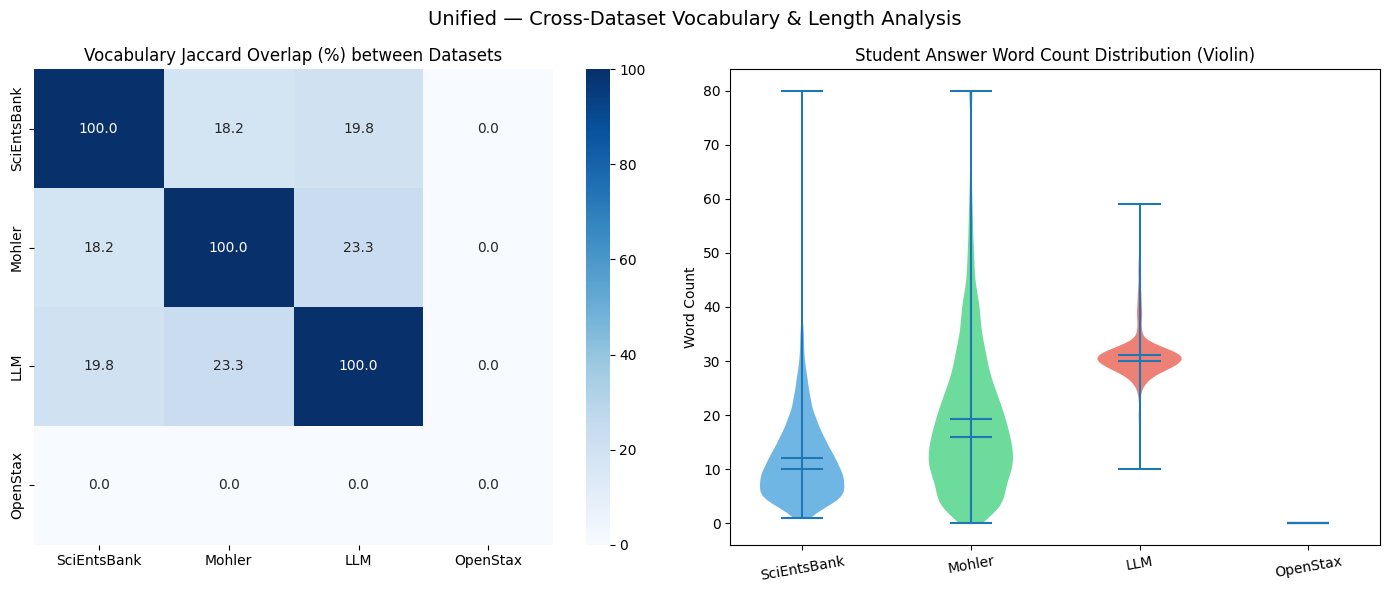

  ✅ Saved → /kaggle/working/eda_outputs/unified_03_vocab_overlap.png


In [29]:
# ============================================================
# CELL 25: UNIFIED — CROSS-DATASET VOCABULARY OVERLAP (Venn)
# ============================================================
# matplotlib-venn đã được cài ở CELL 0
try:
    from matplotlib_venn import venn2, venn3
    HAS_VENN = True
except ImportError:
    HAS_VENN = False

def get_vocab(df_series, min_len=3):
    words = set()
    for text in df_series.fillna('').astype(str):
        for w in re.findall(r'\b[a-z]{3,}\b', text.lower()):
            if w not in STOP_EN:
                words.add(w)
    return words

vocab_scib   = get_vocab(mini_scib['student_answer'])
vocab_mohler = get_vocab(mini_mohler['student_answer'])
vocab_llm    = get_vocab(mini_llm['student_answer'])
vocab_openstax = get_vocab(mini_openstax['student_answer'])

print(f"Vocab sizes: SciEntsBank={len(vocab_scib):,}, Mohler={len(vocab_mohler):,}, "
      f"LLM={len(vocab_llm):,}, OpenStax={len(vocab_openstax):,}")

# Overlap table
all_vocabs = {'SciEntsBank': vocab_scib, 'Mohler': vocab_mohler,
              'LLM': vocab_llm, 'OpenStax': vocab_openstax}
sources = list(all_vocabs.keys())
overlap_matrix = pd.DataFrame(index=sources, columns=sources, dtype=float)
for s1 in sources:
    for s2 in sources:
        v1, v2 = all_vocabs[s1], all_vocabs[s2]
        union = v1 | v2
        overlap_matrix.loc[s1, s2] = (len(v1 & v2) / len(union) * 100) if len(union) > 0 else 0.0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(overlap_matrix.astype(float), annot=True, fmt='.1f', cmap='Blues',
            ax=axes[0], vmin=0, vmax=100)
axes[0].set_title('Vocabulary Jaccard Overlap (%) between Datasets')

# Word count comparison violin
plot_data = []
for src, mini_df in [('SciEntsBank', mini_scib), ('Mohler', mini_mohler),
                      ('LLM', mini_llm), ('OpenStax', mini_openstax)]:
    wc = mini_df['wc_student'].clip(0, 80)
    plot_data.append(wc.values)

vp = axes[1].violinplot(plot_data, positions=[1,2,3,4], showmedians=True, showmeans=True)
for pc, c in zip(vp['bodies'], colors_src):
    pc.set_facecolor(c); pc.set_alpha(0.7)
axes[1].set_xticks([1,2,3,4])
axes[1].set_xticklabels(['SciEntsBank','Mohler','LLM','OpenStax'], rotation=10)
axes[1].set_title('Student Answer Word Count Distribution (Violin)')
axes[1].set_ylabel('Word Count')

plt.suptitle('Unified — Cross-Dataset Vocabulary & Length Analysis', fontsize=14)
plt.tight_layout()
savefig('unified_03_vocab_overlap.png')

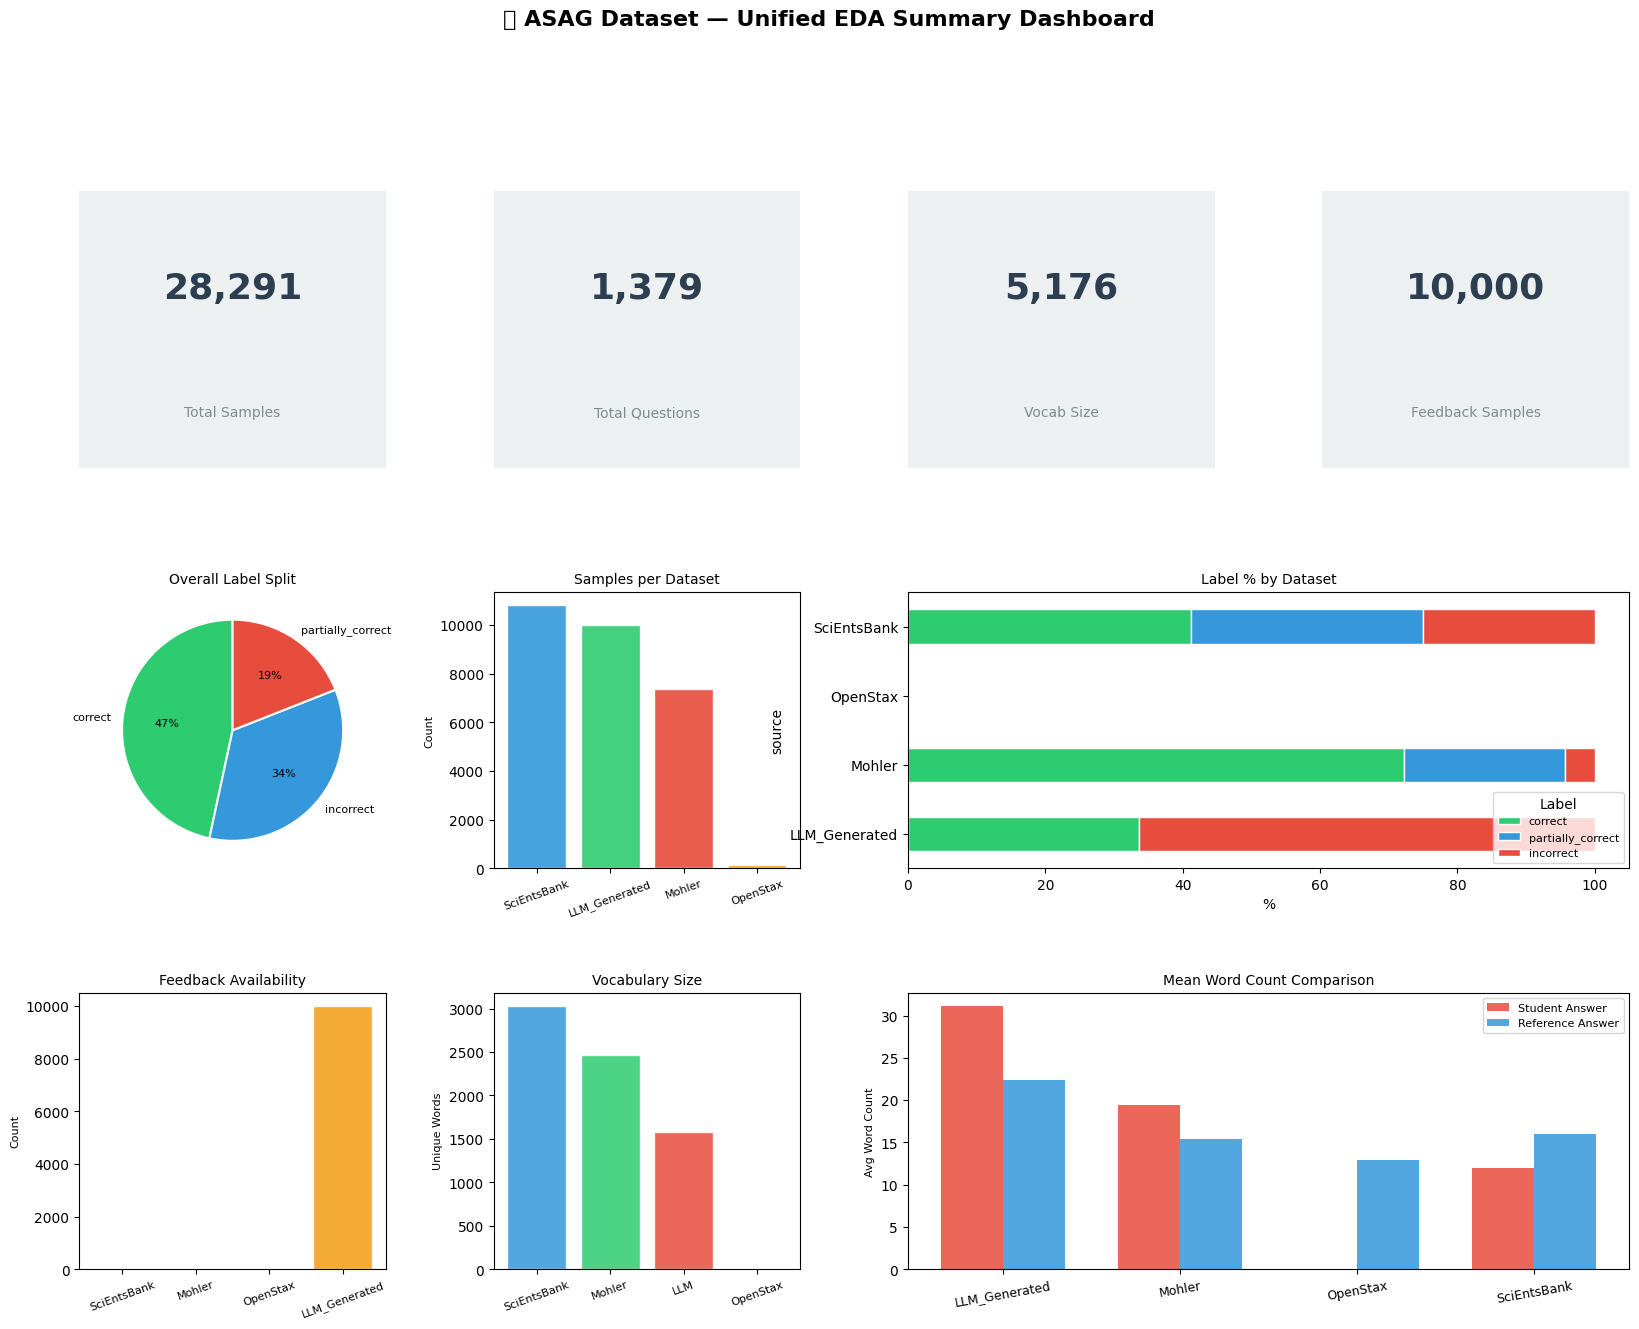

  ✅ Saved → /kaggle/working/eda_outputs/unified_04_summary_dashboard.png


In [30]:
# ============================================================
# CELL 26: UNIFIED — TỔNG HỢP DASHBOARD (Summary Infographic)
# ============================================================
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── Row 0: KPIs ─────────────────────────────────────────────
kpis = [
    ('Total Samples',    f'{len(unified):,}'),
    ('Total Questions',  f'{unified["question"].nunique():,}'),
    ('Vocab Size',       f'{len(vocab_scib | vocab_mohler | vocab_llm | vocab_openstax):,}'),
    ('Feedback Samples', f'{(fb_avail["LLM_Generated"] + fb_avail["OpenStax"]):,}'),
]
for col_i, (label, value) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, col_i])
    ax.text(0.5, 0.65, value, ha='center', va='center', fontsize=26, fontweight='bold',
             color='#2c3e50', transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center', fontsize=10,
             color='#7f8c8d', transform=ax.transAxes)
    ax.set_facecolor('#ecf0f1')
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

# ── Row 1: Label pie, src bar, wc comparison ────────────────
ax1 = fig.add_subplot(gs[1, 0])
counts_3 = unified[unified['label_3way'].isin(['correct','partially_correct','incorrect'])]['label_3way'].value_counts()
ax1.pie(counts_3, labels=counts_3.index, autopct='%1.0f%%',
         colors=['#2ecc71','#3498db','#e74c3c'], startangle=90,
         wedgeprops={'edgecolor':'white','linewidth':1.5}, textprops={'fontsize':8})
ax1.set_title('Overall Label Split', fontsize=10)

ax2 = fig.add_subplot(gs[1, 1])
ax2.bar(src_counts.index, src_counts.values, color=colors_src, edgecolor='white', alpha=0.9)
ax2.set_title('Samples per Dataset', fontsize=10)
ax2.tick_params(axis='x', rotation=20, labelsize=8)
ax2.set_ylabel('Count', fontsize=8)

ax3 = fig.add_subplot(gs[1, 2:])
src_label_pct2 = unified.groupby(['source','label_3way']).size().unstack(fill_value=0)
for src in src_label_pct2.columns:
    if src not in ['correct','partially_correct','incorrect']:
        src_label_pct2 = src_label_pct2.drop(columns=[src], errors='ignore')
src_label_pct2 = src_label_pct2.div(src_label_pct2.sum(axis=1), axis=0) * 100
src_label_pct2[[c for c in ['correct','partially_correct','incorrect'] if c in src_label_pct2.columns]].plot(
    kind='barh', stacked=True, ax=ax3,
    color=['#2ecc71','#3498db','#e74c3c'], edgecolor='white')
ax3.set_title('Label % by Dataset', fontsize=10)
ax3.legend(title='Label', fontsize=8, loc='lower right')
ax3.set_xlabel('%')

# ── Row 2: Feedback availability, word length, vocab ────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(list(fb_avail.keys()), list(fb_avail.values()),
         color=colors_src, edgecolor='white', alpha=0.85)
ax4.set_title('Feedback Availability', fontsize=10)
ax4.tick_params(axis='x', rotation=20, labelsize=8)
ax4.set_ylabel('Count', fontsize=8)

ax5 = fig.add_subplot(gs[2, 1])
vocab_sizes = {k: len(v) for k, v in all_vocabs.items()}
ax5.bar(list(vocab_sizes.keys()), list(vocab_sizes.values()),
         color=colors_src, edgecolor='white', alpha=0.85)
ax5.set_title('Vocabulary Size', fontsize=10)
ax5.tick_params(axis='x', rotation=20, labelsize=8)
ax5.set_ylabel('Unique Words', fontsize=8)

ax6 = fig.add_subplot(gs[2, 2:])
mean_wcs = unified.groupby('source')[['wc_student','wc_ref']].mean()
x = np.arange(len(mean_wcs))
w = 0.35
ax6.bar(x - w/2, mean_wcs['wc_student'], w, label='Student Answer', color='#e74c3c', alpha=0.85)
ax6.bar(x + w/2, mean_wcs['wc_ref'], w, label='Reference Answer', color='#3498db', alpha=0.85)
ax6.set_xticks(x)
ax6.set_xticklabels(mean_wcs.index, rotation=10, fontsize=9)
ax6.set_title('Mean Word Count Comparison', fontsize=10)
ax6.set_ylabel('Avg Word Count', fontsize=8)
ax6.legend(fontsize=8)

fig.suptitle('📊 ASAG Dataset — Unified EDA Summary Dashboard', fontsize=16, fontweight='bold', y=1.01)
savefig('unified_04_summary_dashboard.png')

🎯 PHÂN CHIA VAI TRÒ TỪNG BỘ DỮ LIỆU

📌 DeBERTa Auto-Grading (classification) corpus:
  SciEntsBank  : 10,772 samples
  Mohler       : 7,247 samples
  LLM_Generated: 10,000 samples
  Tổng          : 28,019

📌 T5 Feedback Generation (seq2seq) corpus:
  LLM_Generated: 10,000 samples (có feedback_detailed)
  OpenStax     : ~129 (tùy usable_for_feedback flag)


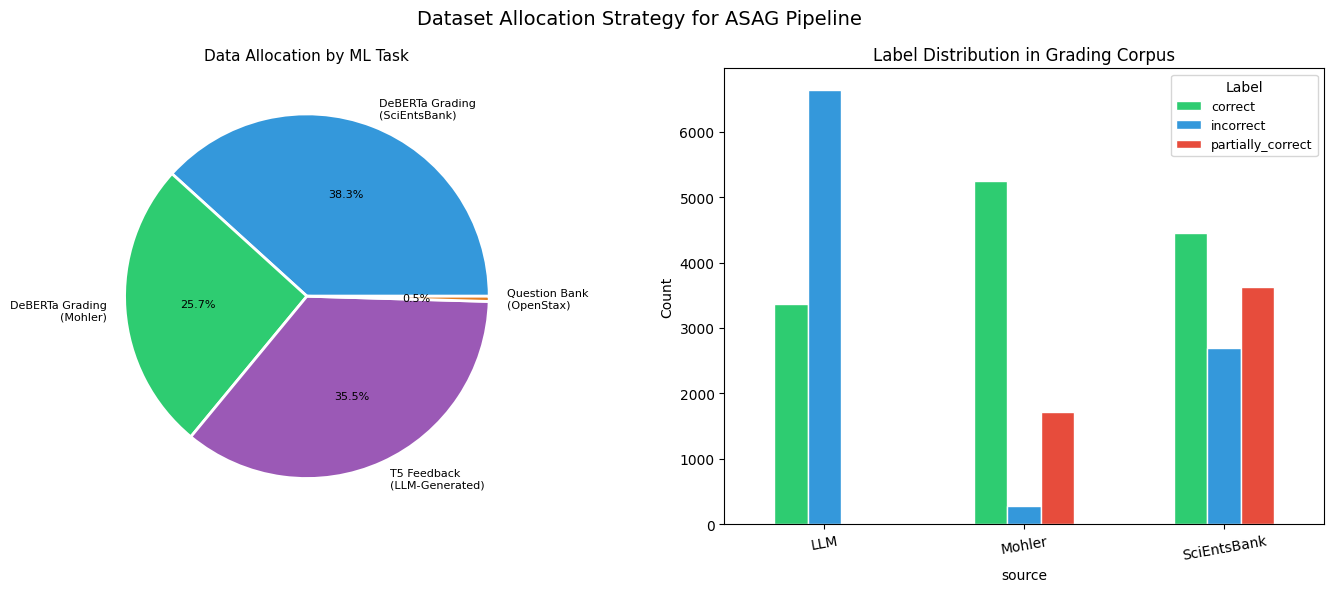

  ✅ Saved → /kaggle/working/eda_outputs/unified_05_data_allocation.png


In [31]:
# ============================================================
# CELL 27: ĐỀ XUẤT PHƯƠNG ÁN HỢP NHẤT — EDA Filtered Dataset
# ============================================================

# ─── Tiêu chí lọc cho Feedback Generation ───────────────────
# 1. Phải có student_answer
# 2. Phải có label_3way hợp lệ (correct/partially_correct/incorrect)
# 3. Phải có reference_answer
# 4. Ưu tiên có feedback_detailed (usable_for_feedback = True)

def build_feedback_corpus(mini_df, has_feedback_col=None):
    """Lọc subset phù hợp cho Feedback Generation."""
    df = mini_df.copy()
    df = df[df['student_answer'].str.len() > 5]
    df = df[df['reference_answer'].str.len() > 5]
    df = df[df['label_3way'].isin(['correct','partially_correct','incorrect'])]
    if has_feedback_col is not None:
        df = df[has_feedback_col.loc[df.index] == True]
    return df

# LLM + OpenStax có feedback → dùng cho Supervised fine-tune T5
# SciEntsBank + Mohler → chỉ có label → dùng cho DeBERTa grading

scib_grading    = build_feedback_corpus(mini_scib)
mohler_grading  = build_feedback_corpus(mini_mohler)
llm_feedback    = mini_llm.copy()   # đã có feedback

print("=" * 60)
print("🎯 PHÂN CHIA VAI TRÒ TỪNG BỘ DỮ LIỆU")
print("=" * 60)
print(f"\n📌 DeBERTa Auto-Grading (classification) corpus:")
print(f"  SciEntsBank  : {len(scib_grading):,} samples")
print(f"  Mohler       : {len(mohler_grading):,} samples")
print(f"  LLM_Generated: {len(llm_feedback):,} samples")
print(f"  Tổng          : {len(scib_grading) + len(mohler_grading) + len(llm_feedback):,}")

print(f"\n📌 T5 Feedback Generation (seq2seq) corpus:")
print(f"  LLM_Generated: {len(llm_feedback):,} samples (có feedback_detailed)")
print(f"  OpenStax     : ~{len(openstax_r):,} (tùy usable_for_feedback flag)")

# Visualize phân chia vai trò
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie: data contribution by task
task_breakdown = {
    'DeBERTa Grading\n(SciEntsBank)': len(scib_grading),
    'DeBERTa Grading\n(Mohler)': len(mohler_grading),
    'T5 Feedback\n(LLM-Generated)': len(llm_feedback),
    'Question Bank\n(OpenStax)': len(openstax_r),
}
axes[0].pie(list(task_breakdown.values()), labels=list(task_breakdown.keys()),
             autopct='%1.1f%%',
             colors=['#3498db','#2ecc71','#9b59b6','#e67e22'],
             wedgeprops={'edgecolor':'white','linewidth':2},
             textprops={'fontsize':8})
axes[0].set_title('Data Allocation by ML Task', fontsize=11)

# Bar: label balance in grading corpus
combined_grading = pd.concat([
    pd.DataFrame({'label': scib_grading['label_3way'], 'source': 'SciEntsBank'}),
    pd.DataFrame({'label': mohler_grading['label_3way'], 'source': 'Mohler'}),
    pd.DataFrame({'label': llm_feedback['label_3way'], 'source': 'LLM'}),
], ignore_index=True)

grading_label_src = combined_grading.groupby(['source','label']).size().unstack(fill_value=0)
grading_label_src.plot(kind='bar', ax=axes[1],
                        color=['#2ecc71','#3498db','#e74c3c'][:len(grading_label_src.columns)],
                        edgecolor='white', rot=10)
axes[1].set_title('Label Distribution in Grading Corpus')
axes[1].set_ylabel('Count')
axes[1].legend(title='Label', fontsize=9)

plt.suptitle('Dataset Allocation Strategy for ASAG Pipeline', fontsize=14)
plt.tight_layout()
savefig('unified_05_data_allocation.png')


╔══════════════════════════════════════════════════════════════════════╗
║         ĐỀ XUẤT CHIA DỮ LIỆU THÀNH 6 BẢNG LOGIC                    ║
╠══════════════════════════════════════════════════════════════════════╣
║  BẢNG 1: dim_question                                                ║
║    question_uid, question, reference_answer,                         ║
║    domain, subdomain, difficulty, source_dataset                     ║
║    → Nguồn: SciEntsBank, Mohler, LLM, OpenStax                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  BẢNG 2: fact_answer                                                 ║
║    sample_id (PK), question_uid (FK),                                ║
║    student_answer, source_dataset, split,                            ║
║    is_synthetic, is_adversarial, perturbation_type                   ║
║    → Chứa toàn bộ 23,375 câu trả lời sinh viên                      ║
╠═════════════════════════════════════════════════════

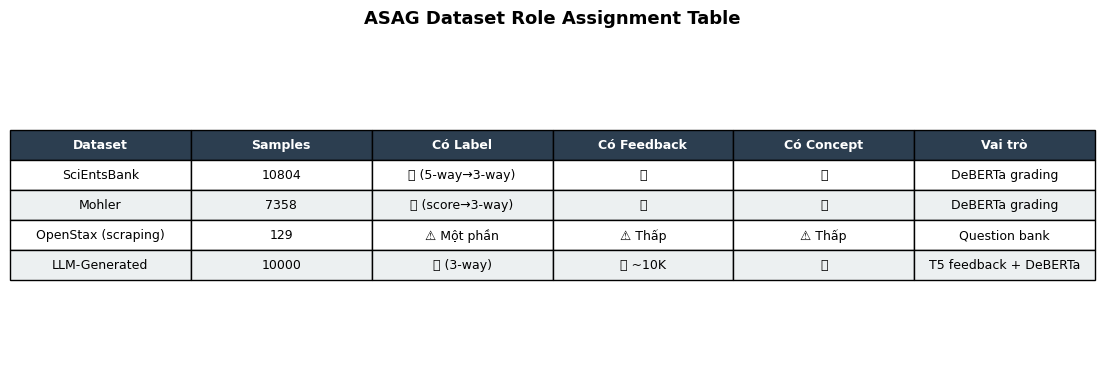

  ✅ Saved → /kaggle/working/eda_outputs/unified_06_dataset_roles_table.png

✅ Tất cả 27 biểu đồ đã được lưu tại /kaggle/working/eda_outputs
  📊 llm_01_overview.png
  📊 llm_02_feedback_length.png
  📊 llm_03_wordcloud_concepts.png
  📊 mohler_01_score_label.png
  📊 mohler_02_text_ngrams_wc.png
  📊 mohler_03_inter_rater.png
  📊 openstax_01_completeness.png
  📊 openstax_02_domain_distribution.png
  📊 openstax_03_concept_misconception.png
  📊 scib_01_missing_values.png
  📊 scib_03_text_length.png
  📊 scib_04_wordcloud_by_label.png
  📊 scib_05_ngrams_by_label.png
  📊 scib_06_tfidf_by_label.png
  📊 scib_07_readability.png
  📊 scib_08_lexical_diversity.png
  📊 scib_09_lda_topics.png
  📊 scib_10_lda_topic_by_label.png
  📊 scib_11_tsne_tfidf.png
  📊 scib_12_jaccard_overlap.png
  📊 scib_13_domain_question.png
  📊 unified_01_cross_comparison.png
  📊 unified_02_label_imbalance.png
  📊 unified_03_vocab_overlap.png
  📊 unified_04_summary_dashboard.png
  📊 unified_05_data_allocation.png
  📊 unified_06_

In [32]:
# ============================================================
# CELL 28: SCHEMA ĐỀ XUẤT (Bảng) + SUMMARY TABLE
# ============================================================
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         ĐỀ XUẤT CHIA DỮ LIỆU THÀNH 6 BẢNG LOGIC                    ║
╠══════════════════════════════════════════════════════════════════════╣
║  BẢNG 1: dim_question                                                ║
║    question_uid, question, reference_answer,                         ║
║    domain, subdomain, difficulty, source_dataset                     ║
║    → Nguồn: SciEntsBank, Mohler, LLM, OpenStax                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  BẢNG 2: fact_answer                                                 ║
║    sample_id (PK), question_uid (FK),                                ║
║    student_answer, source_dataset, split,                            ║
║    is_synthetic, is_adversarial, perturbation_type                   ║
║    → Chứa toàn bộ 23,375 câu trả lời sinh viên                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  BẢNG 3: fact_label                                                  ║
║    sample_id (FK), label_2way, label_3way, label_5way,               ║
║    score_raw, score_normalized, annotation_confidence,               ║
║    usable_for_grading                                                ║
║    → Dùng cho DeBERTa grading training                               ║
╠══════════════════════════════════════════════════════════════════════╣
║  BẢNG 4: fact_feedback                                               ║
║    sample_id (FK), feedback_short, feedback_detailed,                ║
║    feedback_type, feedback_tone, usable_for_feedback                 ║
║    → Chỉ LLM-Generated (~10K) có đầy đủ                             ║
║    → Dùng cho T5 fine-tuning (seq2seq)                               ║
╠══════════════════════════════════════════════════════════════════════╣
║  BẢNG 5: bridge_concept_mention                                      ║
║    sample_id (FK), concept, status                                   ║
║    (key_concept / missing_concept / extra_incorrect_claim)           ║
║    → 143,865 bản ghi, dùng cho Neo4j Knowledge Graph                ║
╠══════════════════════════════════════════════════════════════════════╣
║  BẢNG 6: bridge_misconception_mention                                ║
║    sample_id (FK), misconception, kind                               ║
║    (tag / inventory)                                                 ║
║    → 31,670 bản ghi, dùng cho Neo4j Misconception Graph             ║
╚══════════════════════════════════════════════════════════════════════╝
""")

# Visualization: bảng mô tả dataset
summary_data = {
    'Dataset':      ['SciEntsBank', 'Mohler', 'OpenStax (scraping)', 'LLM-Generated'],
    'Samples':      [len(scib_raw), len(mohler_raw), len(openstax_raw), len(llm_raw)],
    'Có Label':     ['✅ (5-way→3-way)', '✅ (score→3-way)', '⚠️ Một phần', '✅ (3-way)'],
    'Có Feedback':  ['❌', '❌', '⚠️ Thấp', '✅ ~10K'],
    'Có Concept':   ['❌', '❌', '⚠️ Thấp', '✅'],
    'Vai trò':      ['DeBERTa grading', 'DeBERTa grading', 'Question bank', 'T5 feedback + DeBERTa'],
}
summary_df = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
tbl = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center', loc='center',
    colColours=['#2c3e50'] * len(summary_df.columns),
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(color='white', fontweight='bold')
        cell.set_facecolor('#2c3e50')
    elif row % 2 == 0:
        cell.set_facecolor('#ecf0f1')
    else:
        cell.set_facecolor('white')

plt.title('ASAG Dataset Role Assignment Table', pad=20, fontsize=13, fontweight='bold')
savefig('unified_06_dataset_roles_table.png')

print(f"\n✅ Tất cả {len(list(EDA_DIR.glob('*.png')))} biểu đồ đã được lưu tại {EDA_DIR}")
for p in sorted(EDA_DIR.glob('*.png')):
    print(f"  📊 {p.name}")